# **Actividad 3 grupal, proyecto transversal:** Clasificación preliminar de pacientes de urgencias mediante técnicas no supervisadas 
### **Aprendizaje Automático II**
### **Universidad Internacional de la Rioja**
### **Alumnos:** 
- Pedro Delgado de Robles Munaiz 
- Alex Rubiño Fernández 
- Eloi Graña Molanes 
- Juan Medina Martínez 
- Christian Sucuzhañay Carchi

### **Ejercicio 1:** Carga y limpieza del conjunto de datos. Identifica y corrige los errores o valores anómalos en las variables numéricas. Imputa, elimina o justifica las decisiones sobre los valores perdidos o las codificaciones incorrectas. 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv(
    'Actividades_gcd_aa2_act3_proy_4P_dataset.csv', 
    sep=';',                           
    decimal=',',         
    encoding='latin1'            
)

df.head()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,...,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage
0,2,2,71,3,3,2,right ocular pain,1,1,2,...,36.6,100,2,Corneal abrasion,1,4,2,86,5.00,1
1,1,1,56,12,3,2,right forearm burn,1,1,2,...,36.5,NaN,4,"Burn of hand, firts degree dorsum",1,5,4,64,3.95,1
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2,...,36.6,98,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,1.00,1
3,1,2,71,8,1,1,ascites tapping,1,1,3,...,36.5,NaN,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,9.83,1
4,1,2,58,4,3,1,"distension, abd",1,1,3,...,36.5,NaN,4,Ascites,1,5,8,109,6.60,1


Después de probar varios tipos de encoding, 'latin1' ha sido el que nos permita cargar el archivo. Esto puede deberse a caracteres especiales que no estén presentes en otros tipos como 'utf-8'.

| Variable | Descripción | Tipo de valor | Valores mínimos y máximos aceptables | Rangos normales |
| :--- | :--- | :--- | :--- | :--- |
| *Group* | Tipo de centro ED (1 = Local 3º nivel, 2 = Regional 4º nivel) | Categórico (Entero, Nominal) | 1 - 2 | N/A |
| *Sex* | Sexo del paciente (1 = Mujer, 2 = Hombre) | Categórico (Entero, Binario) | 1 - 2 | N/A |
| *Age* | Edad del paciente | Entero | 0 - 120 | N/A |
| *Patients number per hour* | Número de pacientes atendidos por hora | Entero | 0 - 100 | N/A |
| *Arrival mode* | Medio de transporte (1 = A pie, 2 = Ambulancia pública, etc.) | Categórico (Entero, Nominal) | Según rango BBDD | N/A |
| *Injury* | Si el paciente presenta lesión (1 = No, 2 = Sí) | Categórico (Entero, Binario) | 1 - 2 | N/A |
| *Chief complain* | Queja principal expresada por el paciente | Texto (String) | N/A | N/A |
| *Mental* | Nivel de conciencia (1 = Alerta, 2 = Verbal, 3 = Dolor, 4 = Sin respuesta) | Categórico (Entero, Ordinal) | 1 - 4 | N/A |
| *Pain* | Si el paciente refiere dolor (1 = Sí, 0 = No) | Categórico (Entero, Binario) | 0 - 1 | N/A |
| *NRS pain* | Valoración numérica del dolor por parte de enfermería | Entero | Según rango BBDD | N/A |
| *SBP* | Presión arterial sistólica en mmHg | Entero | 40 - 300 | 90 - 120 mmHg |
| *DBP* | Presión arterial diastólica en mmHg | Entero | 20 - 200 | 60 - 80 mmHg |
| *HR* | Pulsaciones por minuto | Entero | 20 - 250 | 60 - 100 lpm |
| *RR* | Respiraciones por minuto | Entero | 0 - 80 | 12 - 20 rpm |
| *BT* | Temperatura en grados centígrados | Flotante (Decimal) | 30.0 - 45.0 | 36.1 - 37.2 °C |
| *Saturation* | Porcentaje de saturación de oxígeno | Entero | 0 - 100 | 95% - 100% |
| *KTAS RN* | Nivel de triaje asignado por enfermería (1–5) | Categórico (Entero, Ordinal) | 1 - 5 | N/A |
| *Diagnosis in ED* | Diagnóstico inicial durante la atención en urgencias | Texto (String) | N/A | N/A |
| *Disposition* | Resultado de la atención (1 = Alta, 2 = Ingreso, etc.) | Categórico (Entero, Nominal) | Según rango BBDD | N/A |
| *KTAS expert* | Nivel de triaje asignado por un experto (1–5) | Categórico (Entero, Ordinal) | 1 - 5 | N/A |
| *Error group* | Evaluación del error en el triaje | Categórico (Entero o Texto, Ordinal) | Según rango BBDD | N/A |
| *Length of stay min* | Tiempo total en urgencias en minutos | Entero | 0 - inf | N/A |
| *KTAS duration min* | Minutos hasta la asignación del nivel KTAS | Entero o Flotante | 0 - inf | N/A |
| *Mistriage* | Indicador de triaje incorrecto (0 = correcto, 1 = incorrecto) | Categórico (Entero, Binario) | 0 - 1 | N/A |

Al analizar la tabla presente en el enunciado de la actividad hemos establecido un rango aceptable de medidas que nos podemos encontrar para así poder detectar aquellas situaciones en el que algún dato no tiene sentido.
Para aquellas en las que el propio enunciado nos da los valores posibles se ha incluido dicho rango. Si el rango aparece incompleto en el enunciado se ha establecido el rango que nos salga al comprobar el archivo .csv (Según rango BBDD). 
Finalmente, para aquellas medidas clínicas se ha preguntado a la IA acerca de el mínimo y máximo de cada variable que sea compatible con la vida y un rango normal esperable en una persona sana. En una situación real, estos datos se preguntarían a un experto en el sector para el que estuvieramos realizando dicho análisis pero al no contar con el experto se ha simulado vía IA.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Group                     1267 non-null   int64  
 1   Sex                       1267 non-null   int64  
 2   Age                       1267 non-null   int64  
 3   Patients number per hour  1267 non-null   int64  
 4   Arrival mode              1267 non-null   int64  
 5   Injury                    1267 non-null   int64  
 6   Chief_complain            1267 non-null   object 
 7   Mental                    1267 non-null   int64  
 8   Pain                      1267 non-null   int64  
 9   NRS_pain                  1267 non-null   object 
 10  SBP                       1267 non-null   object 
 11  DBP                       1267 non-null   object 
 12  HR                        1267 non-null   object 
 13  RR                        1267 non-null   object 
 14  BT      

Con esta información, nos resaltan dos dudas:
1. ¿Por qué existen 7 variables de tipo object cuando claramente deberían ser de tipo numérico(int64 o float64)?
2. ¿Por qué existen tantos nulos en la variable Saturation?

Vamos a tratar de resolver primero las 7 variables mal clasificadas como object

In [5]:
# 1. Definimos un diccionario con los tipos de datos esperados según nuestro análisis previo.
# Incluimos 'float64' en las numéricas enteras porque Pandas convierte int a float si hay valores nulos (NaN).
tipos_esperados = {
    'Group': ['int64', 'float64'],
    'Sex': ['int64', 'float64'],
    'Age': ['int64', 'float64'],
    'Patients number per hour': ['int64', 'float64'],
    'Arrival mode': ['int64', 'float64'],
    'Injury': ['int64', 'float64'],
    'Chief_complain': ['object', 'string'],
    'Mental': ['int64', 'float64'],
    'Pain': ['int64', 'float64'],
    'NRS_pain': ['int64', 'float64'],
    'SBP': ['int64', 'float64'],
    'DBP': ['int64','float64'],
    'HR': ['int64', 'float64'],
    'RR': ['int64', 'float64'],
    'BT': ['float64'],
    'Saturation': ['int64', 'float64'],
    'KTAS_RN': ['int64', 'float64'],
    'Diagnosis in ED': ['object', 'string'],
    'Disposition': ['int64', 'float64'],
    'KTAS_expert': ['int64', 'float64'],
    'Error_group': ['int64', 'object'], 
    'Length of stay_min': ['int64', 'float64'],
    'KTAS duration_min': ['int64','float64'],
    'mistriage': ['int64', 'float64'],
}

# Bucle actualizado para revisar valores únicos, nulos y coherencia de tipos de datos
for col in df.columns:
    print(f"=== Variable: {col} ===")
    
    # 2. Validación del Tipo de Dato
    tipo_actual = str(df[col].dtype)
    esperado = tipos_esperados.get(col, ['Desconocido'])
    
    print(f"Tipo de dato actual: {tipo_actual}")
    print(f"Tipo de dato esperado: {' o '.join(esperado) if esperado != ['Desconocido'] else 'No definido'}")
    
    if tipo_actual not in esperado and esperado != ['Desconocido']:
        print(f"⚠️ Alerta de Tipo: ¡Debería ser {' o '.join(esperado)} pero se detectó {tipo_actual}!")
    
    # 3. Calculamos y mostramos la cantidad de valores NO nulos
    no_nulos = df[col].count()
    print(f"Valores no nulos: {no_nulos}")
    
    # 4. Obtenemos los valores únicos
    valores_unicos = df[col].unique()
    total_unicos = len(valores_unicos)
    print(f"Cantidad total de valores únicos: {total_unicos}")
    
    # 5. Mostramos todos si son pocos (categorías), o un recorte si son muchos
    if total_unicos <= 150:
        print(f"Valores reales en el dataset: {valores_unicos}")
    else:
        print(f"Primeros 10 valores únicos: {valores_unicos[:10]} ...")
    
    # 6. Si hay valores nulos (NaN), mostramos la alerta
    nulos = df[col].isna().sum()
    if nulos > 0:
        print(f"⚠️ Alerta de Nulos: Contiene {nulos} valores nulos (NaN)")
        
    print("-" * 50)

=== Variable: Group ===
Tipo de dato actual: int64
Tipo de dato esperado: int64 o float64
Valores no nulos: 1267
Cantidad total de valores únicos: 2
Valores reales en el dataset: [2 1]
--------------------------------------------------
=== Variable: Sex ===
Tipo de dato actual: int64
Tipo de dato esperado: int64 o float64
Valores no nulos: 1267
Cantidad total de valores únicos: 2
Valores reales en el dataset: [2 1]
--------------------------------------------------
=== Variable: Age ===
Tipo de dato actual: int64
Tipo de dato esperado: int64 o float64
Valores no nulos: 1267
Cantidad total de valores únicos: 81
Valores reales en el dataset: [71 56 68 58 54 49 78 32 38 43 45 53 55 65 69 20 79 24 59 77 37 62 74 44
 16 19 27 30 47 48 87 21 34 36 52 70 81 89 39 29 64 72 83 23 25 26 22 82
 33 61 75 18 42 66 76 85 73 84 50 28 60 67 80 90 92 57 88 63 35 46 17 31
 40 41 51 86 94 91 93 95 96]
--------------------------------------------------
=== Variable: Patients number per hour ===
Tipo de da

Hemos identificado que existen diferentes tipos de nulos (??, nan, #BOÞ!), así como que la variable BT están los decimales escritos con punto en lugar de con coma como sí lo estaba 'KTAS duration_min'.

Vamos a codificar estos valores como nulos, y corregir la variable BT para pasarlas todas a tipo numérico.

In [6]:
# 1. Limpiamos la basura general
# valores_nulos = ['??', 'nan', 'NAN', 'NaN', '#BOÞ!', ' ', '']
valores_nulos = ['??', 'nan', '#BOÞ!']
df.replace(valores_nulos, np.nan, inplace=True)

# 2. Seleccionamos las variables que están en tipo object pero que deberían ser enteras o decimales
cols_enteras = ['NRS_pain', 'SBP', 'DBP', 'HR', 'RR', 'Saturation']
cols_decimales = ['BT'] 

# 3. Convertimos a numérico
for col in cols_enteras:
    df[col] = pd.to_numeric(df[col]).astype('Int64')

# 4. La temperatura la dejamos como float normal (float64)
for col in cols_decimales:
    df[col] = pd.to_numeric(df[col]).astype('float64')

# Verificamos los nuevos tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Group                     1267 non-null   int64  
 1   Sex                       1267 non-null   int64  
 2   Age                       1267 non-null   int64  
 3   Patients number per hour  1267 non-null   int64  
 4   Arrival mode              1267 non-null   int64  
 5   Injury                    1267 non-null   int64  
 6   Chief_complain            1262 non-null   object 
 7   Mental                    1267 non-null   int64  
 8   Pain                      1267 non-null   int64  
 9   NRS_pain                  711 non-null    Int64  
 10  SBP                       1242 non-null   Int64  
 11  DBP                       1238 non-null   Int64  
 12  HR                        1247 non-null   Int64  
 13  RR                        1245 non-null   Int64  
 14  BT      

Al resolver el problema de los nulos mal codificados y los tipos de variables vemos que existen varios nulos más a parte de los vistos anteriormente. Nos llaman la atención especialmente la variable NRS_Pain y Saturation.

Vamos primero con NRS_Pain y para ello vamos a visualizar primero las estadísticas principales de cada variable.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Group,1267.0,1.456985,0.498343,1.0,1.0,1.0,2.0,2.0
Sex,1267.0,1.521705,0.499726,1.0,1.0,2.0,2.0,2.0
Age,1267.0,54.423836,19.725033,16.0,37.0,57.0,71.0,96.0
Patients number per hour,1267.0,7.519337,3.160563,1.0,5.0,7.0,10.0,17.0
Arrival mode,1267.0,2.820837,0.807904,1.0,2.0,3.0,3.0,7.0
Injury,1267.0,1.192581,0.394482,1.0,1.0,1.0,1.0,2.0
Mental,1267.0,1.105762,0.447768,1.0,1.0,1.0,1.0,4.0
Pain,1267.0,0.563536,0.496143,0.0,0.0,1.0,1.0,1.0
NRS_pain,711.0,4.104079,1.419332,1.0,3.0,4.0,5.0,10.0
SBP,1242.0,133.648953,27.275639,50.0,114.0,130.0,150.0,275.0


Con esta tabla nos resaltan dos dudas:
1. El rango de NRS_pain (escala del dolor del paciente) va de 1-10,  no empieza en 0, valorar si los pacientes con Pain == 0 (no presenta dolor) son los nulos en NRS_pain.
2. En Length of stay_min existe un grupo claro de outliers al ver la diferencia entre el 75% y el valor máximo.
3. El rango de mistriage va de 0 - 2 cuando en el enunciado indica ser 0 y 1 (negativo o positivo).

Vamos a comprobar si la primera duda es cierta o no.

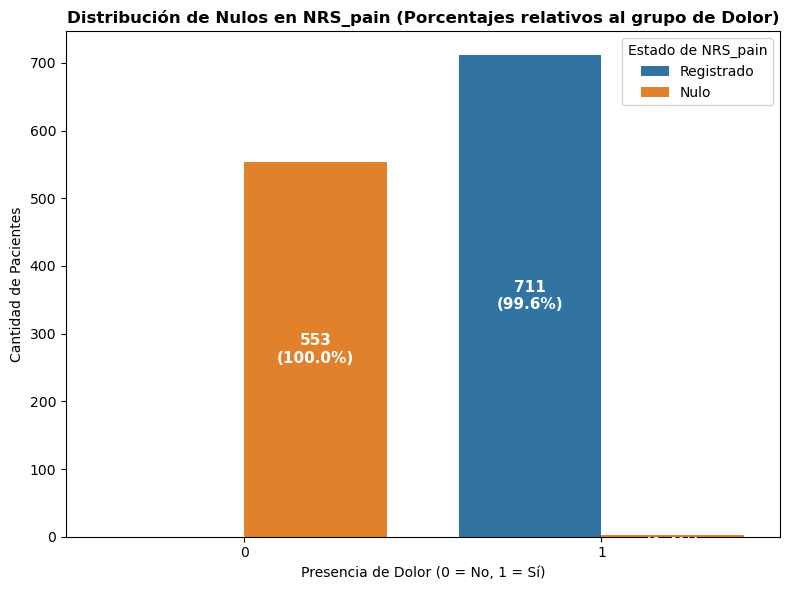

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creamos la columna temporal
df['Falta_NRS_pain'] = df['NRS_pain'].isna().map({True: 'Nulo', False: 'Registrado'})

# 2. Configuramos el gráfico
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=df, 
    x='Pain', 
    hue='Falta_NRS_pain', 
    palette=['#1f77b4', '#ff7f0e'] # Azul y Naranja
)

# 3. CALCULAMOS LOS PORCENTAJES POR GRUPO
# Obtenemos los totales reales para Pain=0 y Pain=1
totales_por_pain = df['Pain'].value_counts()

# Obtenemos el orden de las etiquetas en el eje X para no equivocarnos de grupo
etiquetas_x = [int(float(t.get_text())) for t in ax.get_xticklabels()]

for p in ax.patches:
    altura = p.get_height()
    
    if altura > 0:
        # Encontramos el centro de la barra para saber si pertenece a Pain 0 o Pain 1
        centro_x = p.get_x() + p.get_width() / 2.0
        indice_x = int(round(centro_x)) # Redondea a 0 o 1
        
        # Identificamos el valor real de la variable Pain para esa columna
        valor_pain = etiquetas_x[indice_x]
        
        # Extraemos el total de pacientes de ESE grupo específico
        total_del_grupo = totales_por_pain[valor_pain]
        
        # Calculamos el porcentaje intra-grupo
        porcentaje = f'{(100 * altura / total_del_grupo):.1f}%'
        
        # Anotamos el valor dentro de la barra
        ax.annotate(
            f'{int(altura)}\n({porcentaje})', 
            (centro_x, altura / 2), 
            ha='center', va='center', 
            fontsize=11, color='white', fontweight='bold'
        )

# 4. Ajustamos títulos y diseño
plt.title('Distribución de Nulos en NRS_pain (Porcentajes relativos al grupo de Dolor)', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de Pacientes')
plt.xlabel('Presencia de Dolor (0 = No, 1 = Sí)')

handles, _ = ax.get_legend_handles_labels()
plt.legend(title='Estado de NRS_pain')

plt.tight_layout()
plt.show()

# 5. Eliminamos la columna temporal
df = df.drop(columns=['Falta_NRS_pain'])

Como vemos en este gráfico, En aquellos en lo que la variable Pain (presencia de dolor) es 0 (negativo) son el 100% negativos para la variable NRS_pain (escala del dolor). Sin embargo, en aquellos con Pain == 1 el 99'6% de los datos tienen registros.

Vamos a solucionar este problema sustituyendo por 0 los nulos en NRS_pain para aquellos que tengan un 0 en la variable Pain.

In [9]:
# Asignamos un 0 en NRS_pain a todos los pacientes donde Pain sea igual a 0
df.loc[df['Pain'] == 0, 'NRS_pain'] = 0

# Verificamos que no haya nulos en NRS_pain
df['NRS_pain'].isna().sum()

3

Ahora solo tenemos 3 nlos en la variable NRS_pain que es mucho más coherente con el resto de variables. 
Resolveremos este problema de los 3 nulos más adelante.

Ahora tratemos de resolver los nulos en la variable Saturation.

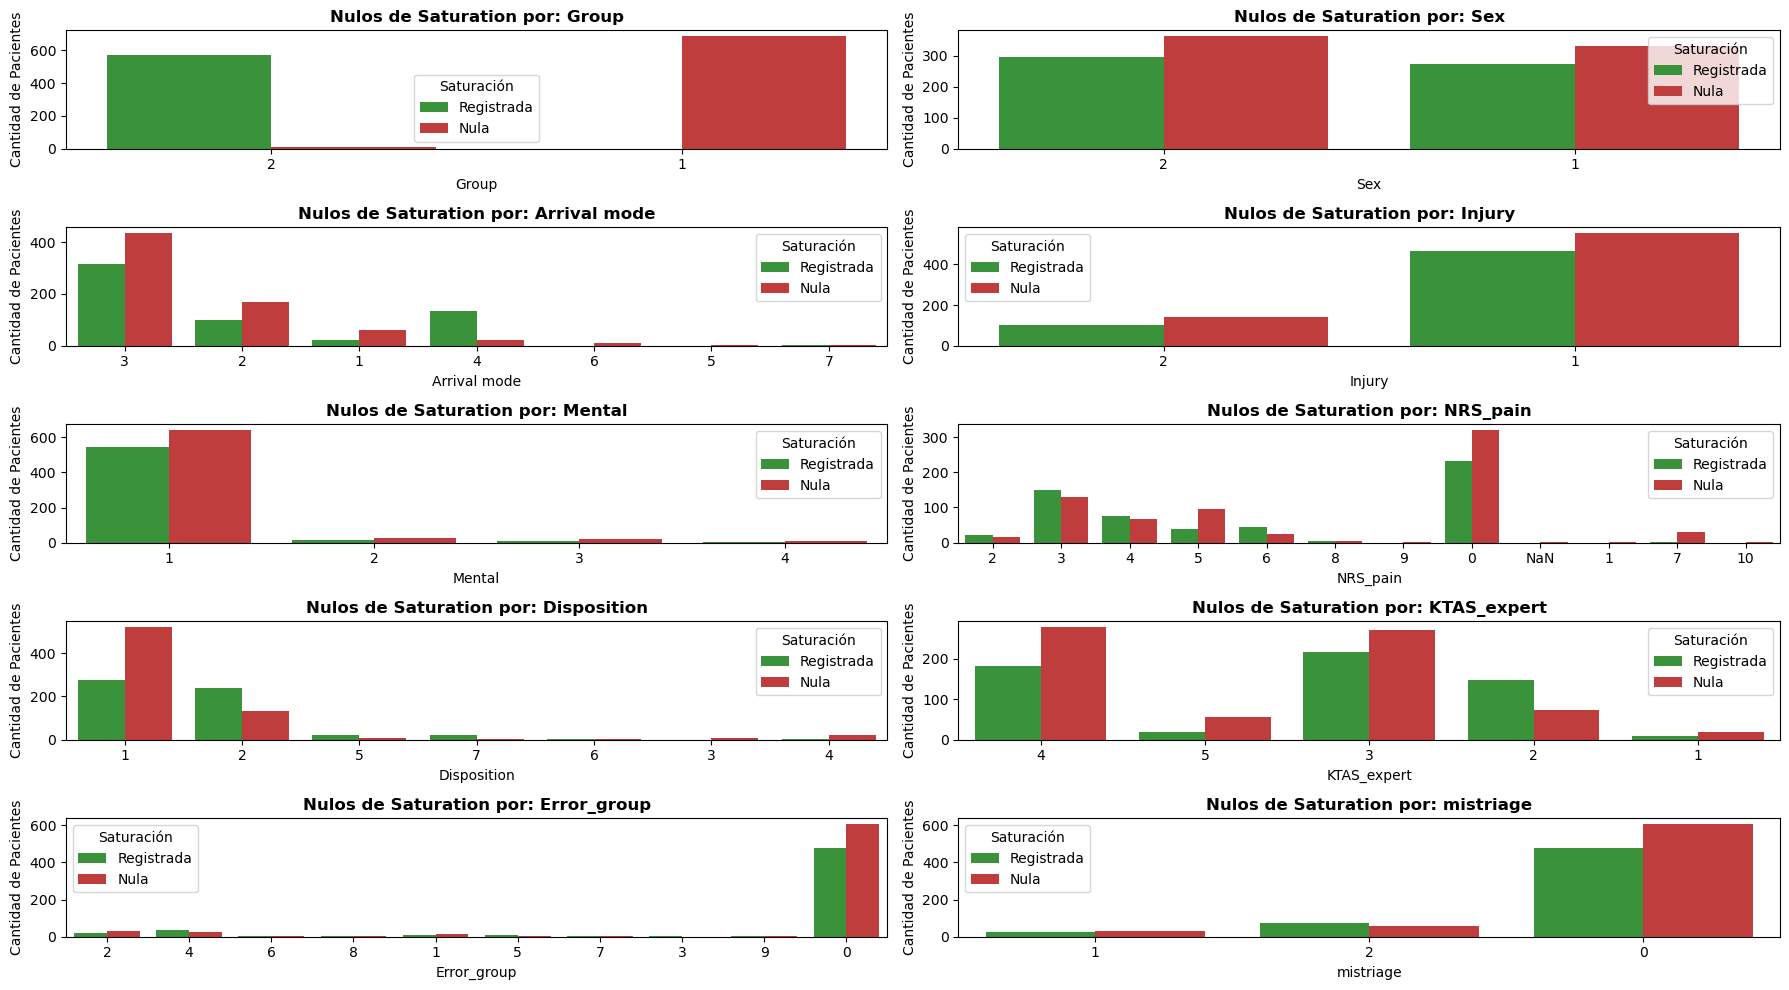

In [10]:
# 1. Creamos una columna temporal que sea True si Saturation es nulo, y False si no lo es
df['Falta_Saturacion'] = df['Saturation'].isna().map({True: 'Nula', False: 'Registrada'})

# 2. Elegimos las variables categóricas que queremos visualizar
variables_a_graficar = ['Group', 'Sex', 'Arrival mode', 'Injury', 'Mental', 'NRS_pain', 'Disposition', 'KTAS_expert', 'Error_group', 'mistriage']
# Convertimos a string las categóricas para evitar problemas con pd.NA
for col in variables_a_graficar:
    df[col] = df[col].astype('string').fillna('NaN')
    
# 3. Configuramos el tamaño del panel de gráficos
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(18, 10))
axes = axes.flatten() # Aplanamos el array de ejes para iterar fácilmente

# 4. Generamos un gráfico por cada variable
for i, col in enumerate(variables_a_graficar):
    sns.countplot(
        data=df, 
        x=col, 
        hue='Falta_Saturacion', 
        ax=axes[i], 
        palette={'Registrada': '#2ca02c', 'Nula': '#d62728'}  # mapeo explícito para que el color sea consistente
    )
    
    axes[i].set_title(f'Nulos de Saturation por: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Cantidad de Pacientes')
    axes[i].set_xlabel(col)
    axes[i].legend(title='Saturación')

plt.tight_layout()
plt.show()

df = df.drop(columns=['Falta_Saturacion'])

Al hacer una comparativa de los nulos en la variable Saturation con el resto de las variables categóricas nos damos cuenta que el problema parece estar en la variable Group (Tipo de centro). Para el grupo 1 (Centro Local), todos los registros son nulos para la variable Saturation, mientras que el 2 (Centro Regional) presenta muy pocos datos nulos.

Esto puede deberse a que el centro local no dispone de los medios suficientes para hacer este tipo de prueba o que los casos más graves sean derivados al centro regional.
Para resolver esta duda vamos a hacer una comparativa de ambos centros a ver si presentan diferencias claras en el resto de variables.

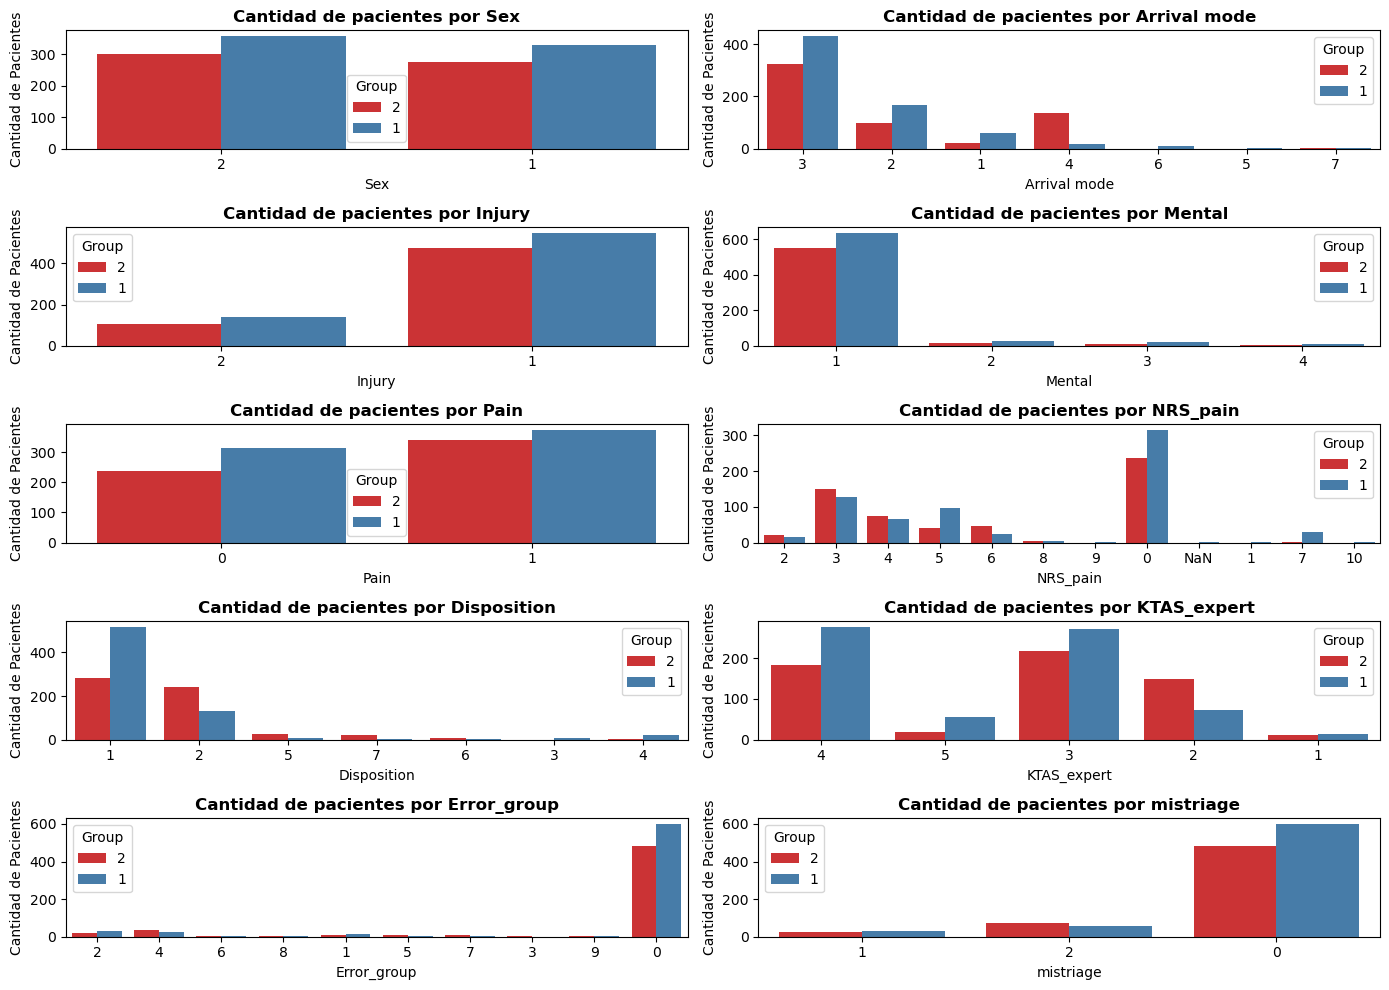

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos las variables categóricas que queremos visualizar
vars_cat = ['Sex', 'Arrival mode', 'Injury', 'Mental', 'Pain', 'NRS_pain', 'Disposition', 'KTAS_expert', 'Error_group', 'mistriage']

# Creamos un panel de 2x3 gráficos
fig, axes = plt.subplots(5, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(vars_cat):
    # sns.countplot cuenta automáticamente las filas y las separa por 'hue' (Group)
    sns.countplot(data=df, x=col, hue='Group', ax=axes[i], palette='Set1')
    axes[i].set_title(f'Cantidad de pacientes por {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Cantidad de Pacientes')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

En cuanto a las variables categóricas, no presentan grandes diferencias entre cada grupo.

Veamos las numéricas.

In [12]:
cols_a_float = ['SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation', 'NRS_pain']
for col in cols_a_float:
    df[col] = df[col].astype('float64')

df['Group'] = df['Group'].astype('int64')

print(df[cols_a_float + ['Group']].dtypes)

SBP           float64
DBP           float64
HR            float64
RR            float64
BT            float64
Saturation    float64
NRS_pain      float64
Group           int64
dtype: object


c:\Users\alexr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\alexr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\alexr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\alexr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

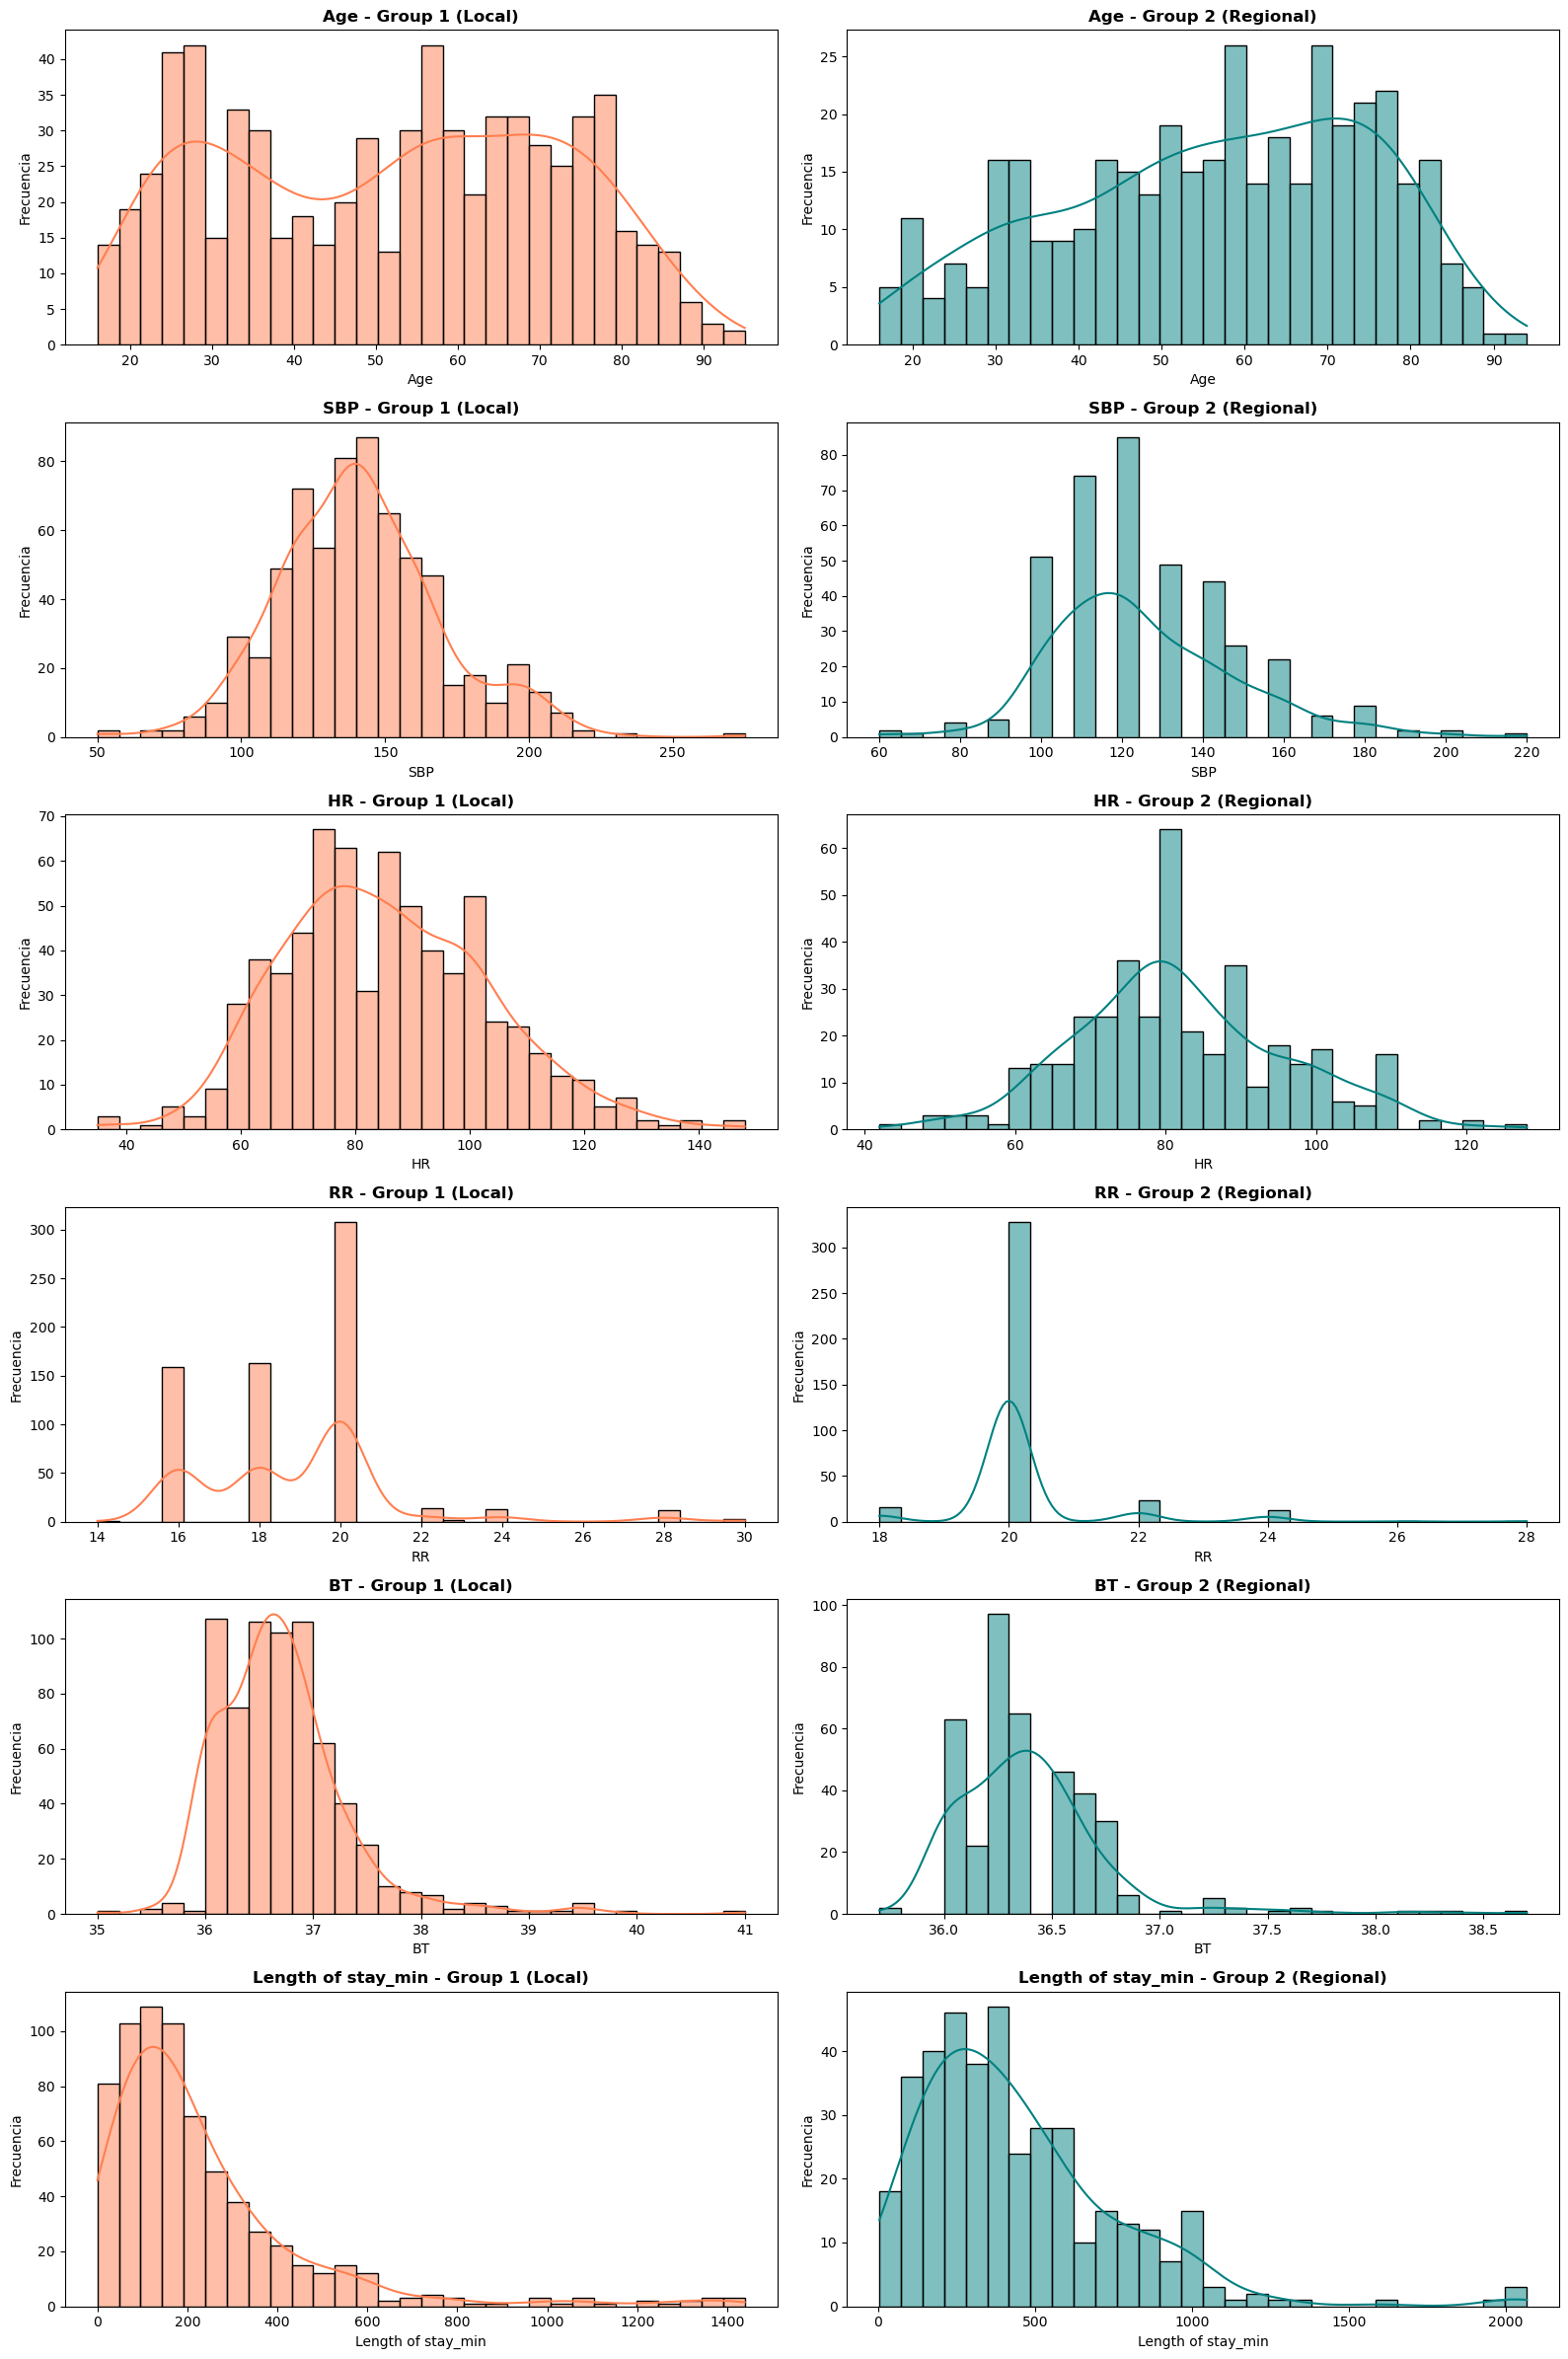

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. FILTRO DE LIMPIEZA: Omitimos los outliers extremos.
# Nos quedamos solo con los pacientes que estuvieron menos de 5000 minutos (aprox 3.5 días)
# Esto eliminará el outlier de 700,000 y alineará las escalas de ambos hospitales.
# Esto se ha hecho después de comprobar que los outliers en esta variable distorsionaban el gráfico 
# y no dejaba a apreciar las diferencias entre ambos grupos en el eje X. 
df_grafico = df[df['Length of stay_min'] < 5000] 

# 2. Definimos las variables continuas que queremos revisar
vars_num = ['Age', 'SBP', 'HR', 'RR', 'BT', 'Length of stay_min']

# 3. Creamos un panel de 6 filas (variables) y 2 columnas (grupos)
fig, axes = plt.subplots(nrows=len(vars_num), ncols=2, figsize=(16, 4 * len(vars_num)))

# 4. Iteramos sobre cada variable usando el dataframe ya filtrado (df_grafico)
for i, col in enumerate(vars_num):
    
    # --- COLUMNA 1: Grupo 1 (Local) ---
    sns.histplot(
        data=df_grafico[df_grafico['Group'] == 1], 
        x=col, 
        kde=True, 
        ax=axes[i, 0], 
        color='coral', 
        bins=30
    )
    axes[i, 0].set_title(f'{col} - Group 1 (Local)', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Frecuencia')
    axes[i, 0].set_xlabel(col)

    # --- COLUMNA 2: Grupo 2 (Regional) ---
    sns.histplot(
        data=df_grafico[df_grafico['Group'] == 2], 
        x=col, 
        kde=True, 
        ax=axes[i, 1], 
        color='teal', 
        bins=30
    )
    axes[i, 1].set_title(f'{col} - Group 2 (Regional)', fontsize=12, fontweight='bold')
    axes[i, 1].set_ylabel('Frecuencia')
    axes[i, 1].set_xlabel(col)


plt.tight_layout()
plt.show()


Las distribuciones numéricas son comparables entre ambos centros. Las únicas diferencias relevantes son la edad (Regional sesgado a mayores) y la duración de la estancia (Regional con cola más larga), lo que coincide con un perfil de paciente más complejo en ese centro. Las constantes vitales son prácticamente idénticas entre grupos, lo que valida que podemos imputar la Saturation del Grupo 1 con un modelo entrenado sobre el Grupo 2.

Antes, resolveremos los nulos del resto de variables para que no interfieran en el modelo. Empezamos contando los registros con uno o más nulos (ignorando las variables de tipo object).

In [14]:
# 1. Seleccionamos TODAS las columnas numéricas y EXCLUIMOS 'Saturation' y 'NRS_pain'
columnas_numericas = df.select_dtypes(include=['number']).columns
columnas_a_revisar = columnas_numericas.drop(['Saturation'])

# 2. Contamos cuántas filas tienen al menos un nulo en este nuevo grupo de columnas
pacientes_con_nulos = df[columnas_a_revisar].isna().any(axis=1).sum()

# 3. Calculamos el porcentaje que representa sobre el total
porcentaje_perdida = (pacientes_con_nulos / len(df)) * 100

print(f"Total de registros originales: {len(df)}")
print(f"Registros con nulos (ignorando Saturation): {pacientes_con_nulos}")
print(f"Porcentaje de datos que perderías: {porcentaje_perdida:.2f}%")

Total de registros originales: 1267
Registros con nulos (ignorando Saturation): 37
Porcentaje de datos que perderías: 2.92%


Al representar menos del 3% de del dataset y contar este con 1267 registros podemos asumir la pérdida de dichos registros sin alterar los patrones presentes en el dataset.

In [15]:
# Eliminamos las filas con nulos SOLO en esas columnas numéricas
df_limpio = df.dropna(subset=columnas_a_revisar).copy()

# Verificamos el nuevo tamaño del dataset limpio
print(f"El dataset final tiene {len(df_limpio)} pacientes.")
print(f"El Grupo 1 tiene {len(df_limpio[df_limpio['Group'] == 1])} pacientes.")
print(f"El Grupo 2 tiene {len(df_limpio[df_limpio['Group'] == 2])} pacientes.")

El dataset final tiene 1230 pacientes.
El Grupo 1 tiene 665 pacientes.
El Grupo 2 tiene 565 pacientes.


Al eliminar los nulos nos quedamos con 1230 registros. 565 pacientes para predecir los 665 restantes.

Vamos a comprobar que no existan datos fuera de los rangos establecidos previamente por el 'experto'.

In [16]:
# Filtramos pacientes del Grupo 2 y eliminamos cualquier fila que casualmente no tenga saturación
df_g2 = df_limpio[(df_limpio['Group'] == 2) & (df_limpio['Saturation'].notna())]

# Definimos las variables predictoras y el objetivo (Saturación)
features = ['Sex', 'Age', 'Injury', 'Mental', 'NRS_pain', 'SBP', 'HR', 'RR', 'BT'] # Solo incluimos variables previas a la medición de saturación
df_g2[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,561.0,57.381462,18.843641,16.0,44.0,58.0,74.0,96.0
NRS_pain,561.0,2.311943,2.141599,0.0,0.0,3.0,4.0,8.0
SBP,561.0,124.937611,22.361591,70.0,110.0,120.0,140.0,220.0
HR,561.0,82.114082,14.896350,32.0,72.0,80.0,92.0,140.0
RR,561.0,20.242424,1.139416,18.0,20.0,20.0,20.0,28.0
BT,561.0,36.441355,0.403690,36.0,36.2,36.4,36.6,38.7


Vemos que aunque existan casos inusuales están todos dentro del rango permitido.

Vamos a dividir el grupo 2 en entrenamiento y test para evaluar que el modelo creado sea reproducible sobre nuevos datos.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import pandas as pd

# ---------------------------------------------------------
# PASO 1: Preparar los datos del Grupo 2 (Los que enseñarán al modelo)
# ---------------------------------------------------------
# Filtramos pacientes del Grupo 2 y eliminamos cualquier fila que no tenga saturación
df_g2 = df_limpio[(df_limpio['Group'] == 2) & (df_limpio['Saturation'].notna())]

# Definimos las variables predictoras y el objetivo (Saturación)
features = ['Sex', 'Age', 'Injury', 'Mental', 'NRS_pain', 'SBP', 'HR', 'RR', 'BT'] # Solo incluimos variables previas a la medición de saturación
X_g2 = df_g2[features]
y_g2 = df_g2['Saturation']

# ---------------------------------------------------------
# PASO 2: Crear el modelo y comprobar la tasa de error
# ---------------------------------------------------------
# Dividimos el Grupo 2 en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_g2, y_g2, test_size=0.2, random_state=42)

# Entrenamos un Random Forest Regressor
modelo_sat = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_sat.fit(X_train, y_train)

# Hacemos predicciones sobre el 20% de prueba
predicciones_test = np.round(modelo_sat.predict(X_test))

# Calculamos el Error Absoluto Medio (MAE)
error_mae = mean_absolute_error(y_test, predicciones_test)
print(f"TASA DE ERROR DEL MODELO: Me equivoco en promedio por {error_mae:.2f} % de saturación.")



TASA DE ERROR DEL MODELO: Me equivoco en promedio por 1.65 % de saturación.


El modelo RandomForest entrenado sobre el 80% del Grupo 2 alcanza un MAE de 1.65% sobre el 20% de validación. Este error es clínicamente despreciable y comparable a la precisión típica de un pulsioxímetro real (~±2%), lo que valida que el modelo es lo suficientemente preciso para imputar la Saturation de los pacientes del Grupo 1.

In [18]:
# ---------------------------------------------------------
# PASO 3: Aplicamos al Grupo 1
# ---------------------------------------------------------

# Reentrenamos el modelo final con TODOS los datos del Grupo 2 (no solo el 80%)
# Una vez validado con el split, aprovechamos toda la información disponible.
modelo_sat_final = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_sat_final.fit(X_g2, y_g2)

# Aislamos al Grupo 1 (los que necesitan la imputación)
df_g1 = df_limpio[df_limpio['Group'] == 1].copy()

# Predecimos su saturación usando el modelo final
X_g1 = df_g1[features]
saturaciones_predichas = np.round(modelo_sat_final.predict(X_g1))

# Asignamos estas predicciones a la columna original del dataset completo
df_limpio.loc[df_limpio['Group'] == 1, 'Saturation'] = saturaciones_predichas

print("¡Imputación del Grupo 1 completada con éxito basándose en la biología del Grupo 2!")

¡Imputación del Grupo 1 completada con éxito basándose en la biología del Grupo 2!


Al tener ya el grupo 1 imputado ahora debemos eliminar los nulos de la variable Saturation que quedan presentes en el grupo 2.

Para ello, vamos a eliminar toddos los nulos presentes en cualquier variable que sea de tipo numérica.

In [19]:
# Seleccionamos todas las columnas numéricas
columnas_numericas = df_limpio.select_dtypes(include=['number']).columns

# Pasar las Int64 sin nulos a int64 normal
for col in ['Sex', 'Arrival mode', 'Injury', 'Mental', 'Disposition', 'KTAS_expert', 'Error_group', 'mistriage']:
    df_limpio[col] = df_limpio[col].astype('int64')

# Eliminamos las filas con nulos SOLO en esas columnas numéricas
df_limpio = df_limpio.dropna(subset=columnas_numericas).copy()

# Verificamos el nuevo tamaño del dataset limpio
print(f"El dataset final tiene {len(df_limpio)} pacientes.")

df_limpio.info()

El dataset final tiene 1226 pacientes.
<class 'pandas.core.frame.DataFrame'>
Index: 1226 entries, 0 to 1266
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Group                     1226 non-null   int64  
 1   Sex                       1226 non-null   int64  
 2   Age                       1226 non-null   int64  
 3   Patients number per hour  1226 non-null   int64  
 4   Arrival mode              1226 non-null   int64  
 5   Injury                    1226 non-null   int64  
 6   Chief_complain            1222 non-null   object 
 7   Mental                    1226 non-null   int64  
 8   Pain                      1226 non-null   int64  
 9   NRS_pain                  1226 non-null   float64
 10  SBP                       1226 non-null   float64
 11  DBP                       1226 non-null   float64
 12  HR                        1226 non-null   float64
 13  RR                        122

Como vemos, ya tenemos todas las variables lista a excepción de las de tipo object que de momento no las vamos a usar.

Vamos a analizar cómo se distribuye cada variable de nuestro dataset limpio.

c:\Users\alexr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\alexr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\alexr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\alexr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

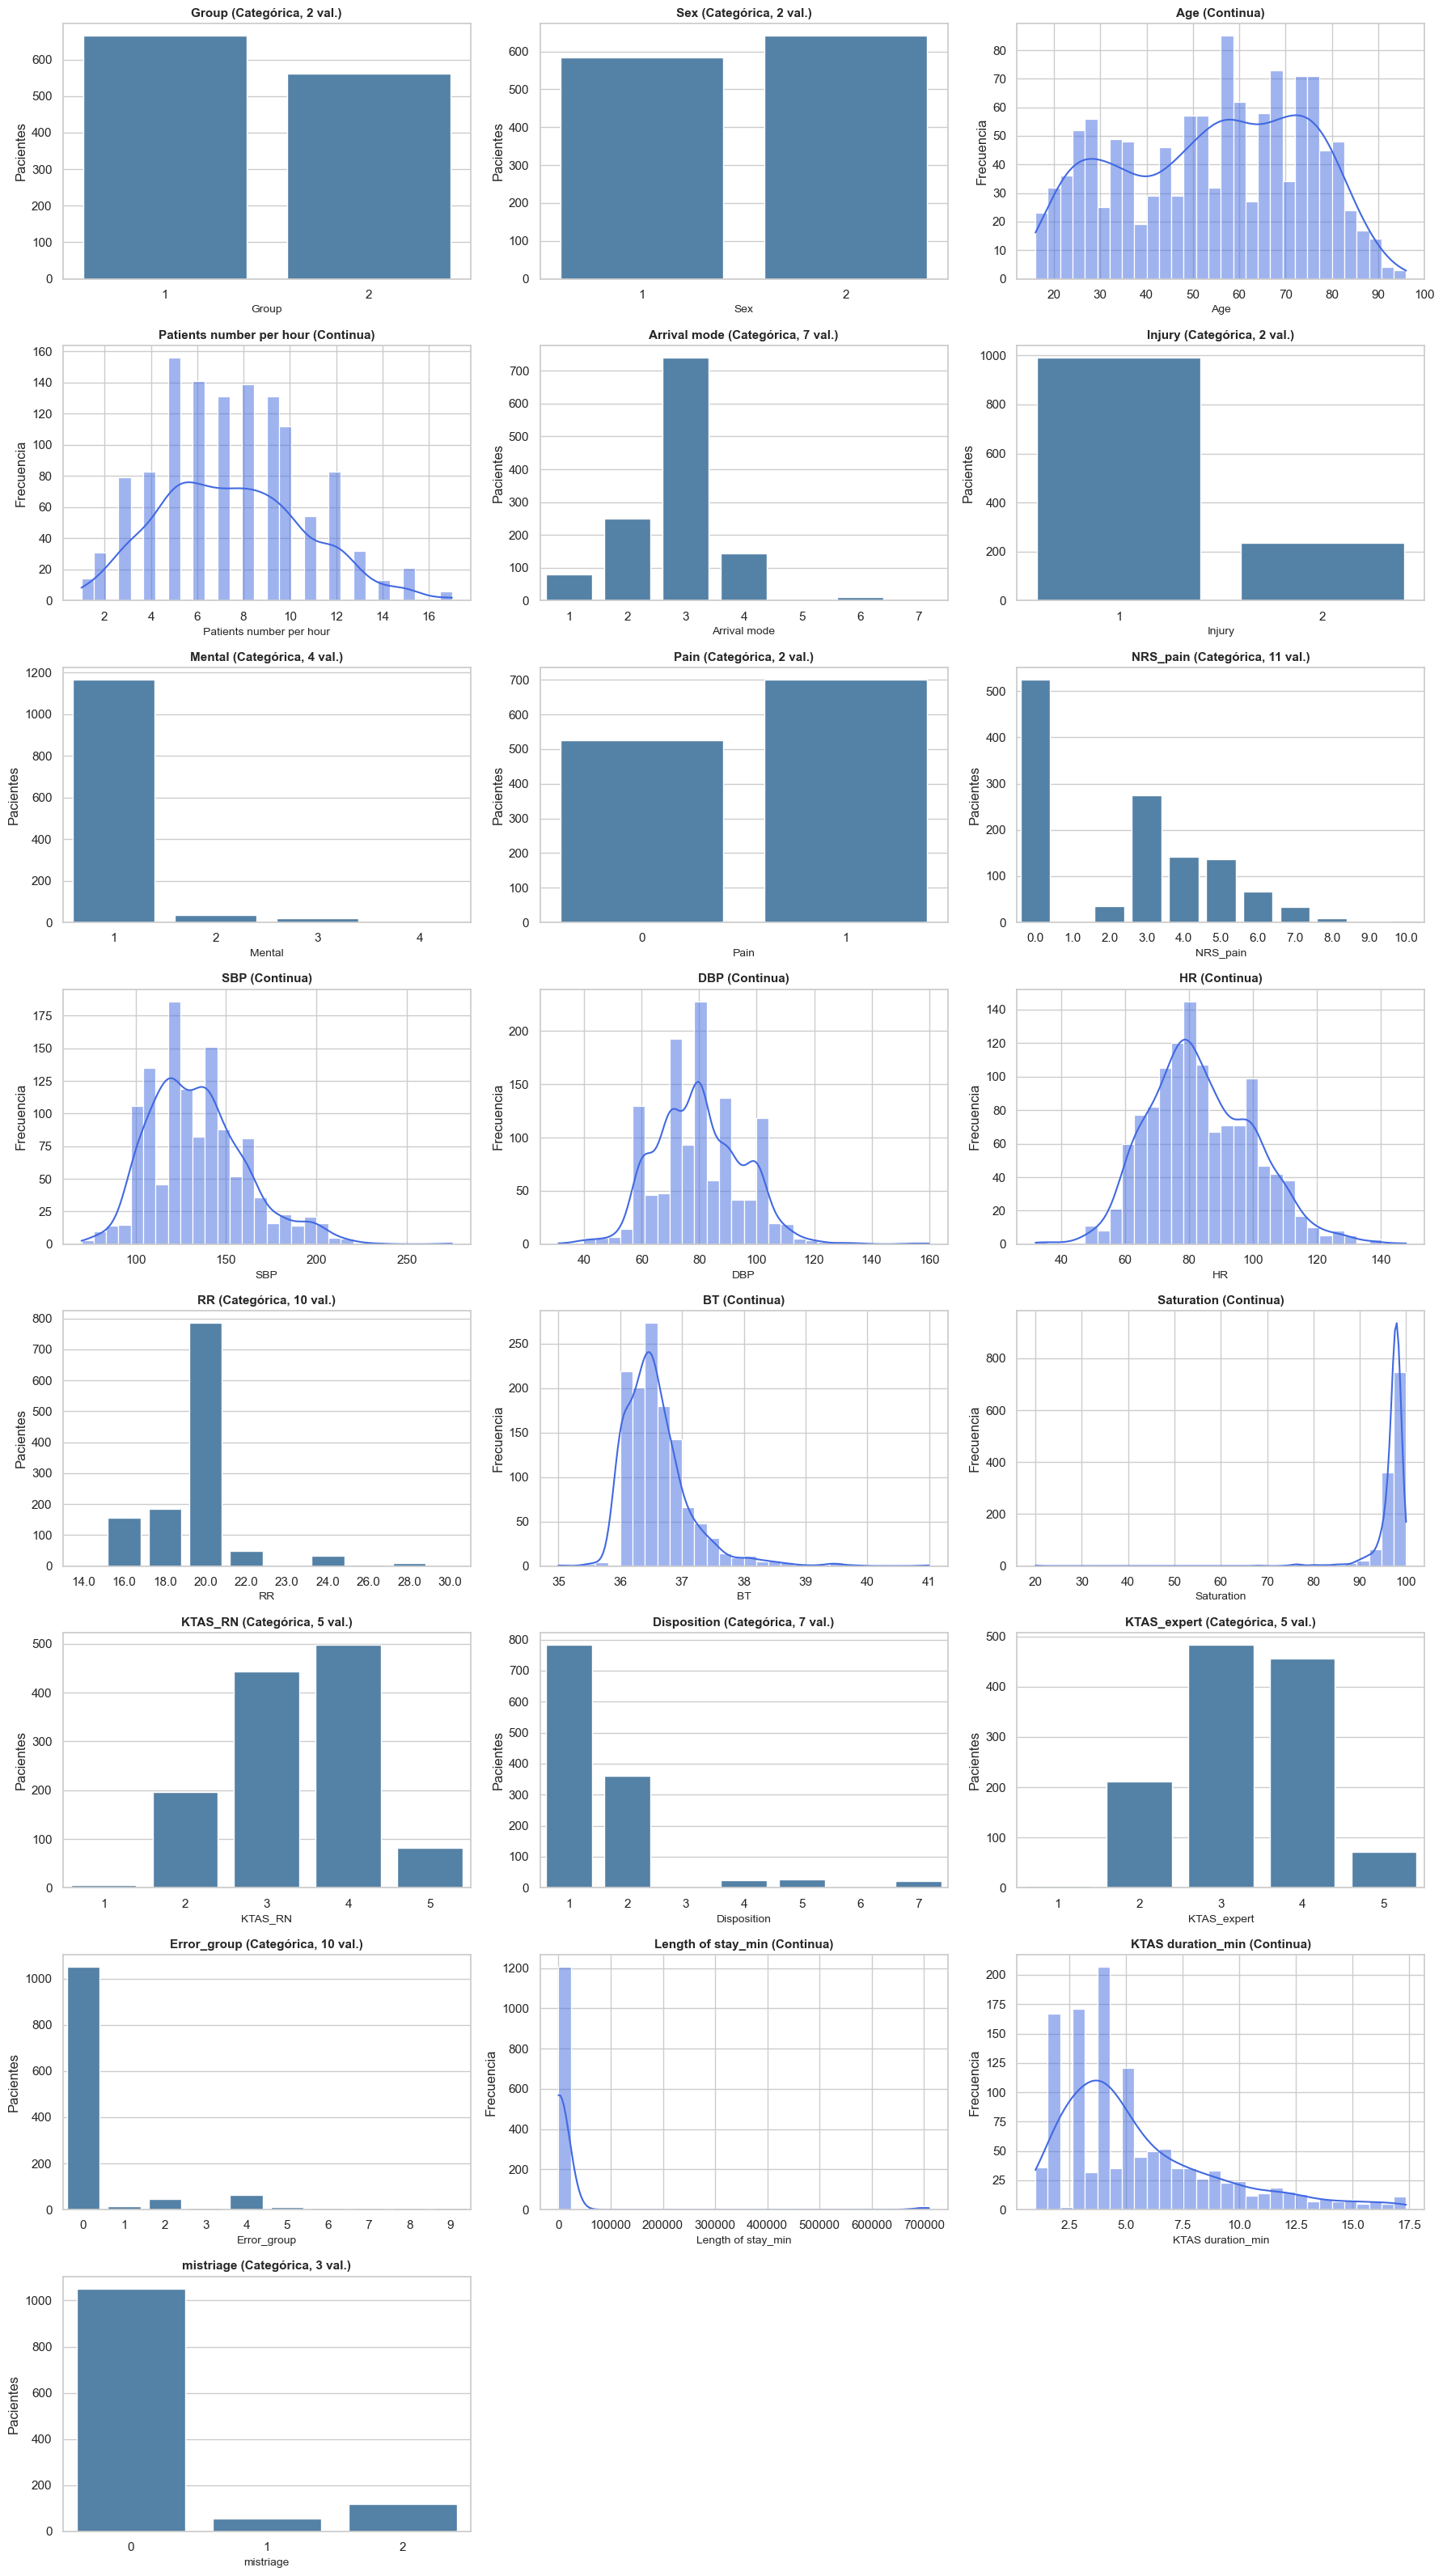

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Seleccionamos todas las variables numéricas
cols_numericas = df_limpio.select_dtypes(include='number').columns
n_vars = len(cols_numericas)

# 2. Configuramos el panel: 3 columnas, filas las que hagan falta
n_cols = 3
n_filas = math.ceil(n_vars / n_cols)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=n_filas, ncols=n_cols, figsize=(18, 4 * n_filas))
axes = axes.flatten()

# 3. Pintamos cada variable en su subplot
for i, col in enumerate(cols_numericas):
    n_unicos = df_limpio[col].nunique()
    
    if n_unicos <= 15:
        # Categórica: countplot
        sns.countplot(data=df_limpio, x=col, ax=axes[i], color='steelblue')
        axes[i].set_title(f'{col} (Categórica, {n_unicos} val.)', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Pacientes')
    else:
        # Continua: histograma con KDE
        sns.histplot(data=df_limpio, x=col, kde=True, bins=30, ax=axes[i], color='royalblue')
        axes[i].set_title(f'{col} (Continua)', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Frecuencia')
    
    axes[i].set_xlabel(col, fontsize=10)

# 4. Ocultamos los subplots sobrantes (si los hay)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Al observar cada variable nos quedan 2 dudas:
1. ¿Los datos de la variable Length of stay_min presentan outliers o son datos mal codificados?
2. ¿Por qué mistriage presenta 3 grupos? ¿Los 0 dentro de Error_group son los mismos que los 0 en mistriage?

In [21]:
import numpy as np
bins = [0, 1440, 2880, 5000, 10000, 50000, np.inf]
labels = ['<24h', '24-48h', '48-83h', '83h-7d', '7d-35d', '>35d']
print("Distribución de Length of stay_min:")
print(pd.cut(df_limpio['Length of stay_min'], bins=bins, labels=labels).value_counts().sort_index())
print(f"\nMáximo: {df_limpio['Length of stay_min'].max()} min")

Distribución de Length of stay_min:
Length of stay_min
<24h      1016
24-48h       5
48-83h       0
83h-7d     117
7d-35d      53
>35d        17
Name: count, dtype: int64

Máximo: 709510 min


Existe un vacío total entre 48h y 83h, seguido de un cluster de pacientes con estancias de varios días a meses (máximo: 709.510 min = 493 días). Este patrón no es natural: si fueran estancias largas legítimas, esperaríamos una distribución continua. Se trata de errores sistemáticos de codificación, posiblemente timestamps mal calculados.

Aplicamos un filtro de 2880 min (48h) como límite, considerando este umbral como la duración máxima razonable para una estancia en urgencias antes de pasar a ingreso. Aprovechamos también para corregir un caso anómalo de Saturation=20 en un paciente KTAS=3 (clínicamente incompatible) sustituyéndolo por la mediana del Grupo 2.

In [22]:
filas_antes = len(df_limpio)

# 1. Outliers en Length of stay (umbral 48h)
df_limpio = df_limpio[df_limpio['Length of stay_min'] <= 2880].copy()

# 2. Saturación anómala (20 con KTAS=3, incompatible clínicamente)
mediana_sat_g2 = df_limpio[df_limpio['Group']==2]['Saturation'].median()
df_limpio.loc[(df_limpio['Group']==2) & (df_limpio['Saturation']==20), 'Saturation'] = mediana_sat_g2

print(f"Filas eliminadas: {filas_antes - len(df_limpio)}")
print(f"Dataset final: {len(df_limpio)} pacientes")

Filas eliminadas: 187
Dataset final: 1039 pacientes


In [23]:
print("Cruce mistriage vs Error_group:")
print(pd.crosstab(df_limpio['mistriage'], df_limpio['Error_group'], margins=True))

print("\nKTAS_RN vs KTAS_expert por categoría de mistriage:")
print(df_limpio.groupby('mistriage').apply(lambda x: (x['KTAS_RN'] - x['KTAS_expert']).describe()))

Cruce mistriage vs Error_group:
Error_group    0   1   2  3   4  5  6  7  8  9   All
mistriage                                           
0            898   0   0  0   0  0  0  0  0  0   898
1              0   5  16  0  22  4  1  0  1  0    49
2              0   5  26  4  30  4  6  3  7  7    92
All          898  10  42  4  52  8  7  3  8  7  1039

KTAS_RN vs KTAS_expert por categoría de mistriage:
           count      mean       std  min  25%  50%  75%  max
mistriage                                                    
0          898.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0
1           49.0 -1.081633  0.276642 -2.0 -1.0 -1.0 -1.0 -1.0
2           92.0  1.108696  0.312963  1.0  1.0  1.0  1.0  2.0


Confirmación del cruce mistriage vs Error_group:

- mistriage = 0: triaje correcto. Coincide con Error_group=0.
- mistriage = 1: overtriage. La enfermera asignó más gravedad de la real (diferencia KTAS = -1.08).
- mistriage = 2: undertriage. La enfermera asignó menos gravedad de la real (diferencia KTAS = +1.11), el error clínicamente más peligroso.

Un 13.6% del dataset corresponde a errores de triaje, lo que abre una línea interesante para el Ej5: comprobar si el clustering puede detectar automáticamente estos pacientes mal clasificados.
Como mistriage, Error_group, KTAS_expert y KTAS_RN son outcomes posteriores al triaje, no se usarán como features en el Ej3, pero servirán como ground truth en el Ej5.

Tras el proceso de limpieza, el dataset final cuenta con pacientes sin nulos en variables numéricas, outliers tratados y decisiones de imputación justificadas:

- NRS_pain: imputación con 0 para Pain=0 (missing estructural).
- Saturation del Grupo 1: imputación con RandomForest entrenado sobre Grupo 2 (MAE 1.65%).
- Eliminación de filas con nulos residuales y outliers extremos en Length of stay_min y Saturation.
- Identificación de mistriage, Error_group, KTAS_expert y KTAS_RN como outcomes del triaje, no aptas como features del clustering.

In [24]:
# Guardar dataset limpio
df_limpio.to_csv('dataset_limpio.csv', index=False)
print(f"Dataset limpio guardado: {len(df_limpio)} pacientes, {len(df_limpio.columns)} columnas")

Dataset limpio guardado: 1039 pacientes, 24 columnas


### **Ejercicio 2:** selecciona un conjunto de variables numéricas relevantes y aplica técnicas de escalado.

Selección de variables relevantes
De las 24 variables del dataset, no todas son aptas para el clustering. Aplicamos los siguientes criterios para descartar:

- Identificadores y metadatos: Group, Patients number per hour → describen el contexto del paciente, no su estado clínico.
- Variables de texto libre: Chief_complain, Diagnosis in ED → tipo object, no procesables sin NLP.
- Outcomes posteriores al triaje: KTAS_RN, KTAS_expert, Error_group, mistriage, Disposition, Length of stay_min, KTAS duration_min → son consecuencias o etiquetas del proceso, no inputs para clasificar pacientes. Usarlas sería data leakage.
- Variables redundantes: Pain (binaria) ya está implícita en NRS_pain (intensidad 0-10).
- Sex: poco discriminatorio clínicamente para este análisis (decisión revisable según resultados).

Nos quedamos con 9 variables clínicamente relevantes: Age, Injury, Mental, NRS_pain, SBP, HR, RR, BT, Saturation. Mezclan datos demográficos (edad), estado neurológico (Mental), dolor (NRS_pain), constantes vitales (SBP, HR, RR, BT, Saturation) y presencia de lesión (Injury).

Estrategia de escalado: enfoque híbrido

K-means es sensible a la escala: variables con rangos grandes (SBP: 50-275) dominarían a las pequeñas (Mental: 1-4) si no se escalan. Por eso aplicamos StandardScaler (media 0, desviación 1) a todas las variables continuas y ordinales.
Sin embargo, Injury es binaria (0/1) y ya está en una escala acotada. Escalarla la distorsionaría sin aportar nada, por lo que la dejamos sin tocar. Antes la mapeamos de 1/2 a 0/1 para que tenga la representación binaria estándar.
Este enfoque híbrido (escalar continuas, dejar binarias en 0/1) es habitual en k-means cuando se mezclan tipos de variables

In [25]:
from sklearn.preprocessing import StandardScaler

# 1. Selección de variables relevantes
columnas_kmeans = ['Age', 'Injury', 'Mental', 'NRS_pain', 'SBP', 'HR', 'RR', 'BT', 'Saturation']
X_kmeans = df_limpio[columnas_kmeans].copy()

# 2. Mapeo de Injury de codificación 1/2 a binaria 0/1
X_kmeans['Injury'] = X_kmeans['Injury'].map({1: 0, 2: 1})

# 3. Escalado híbrido: StandardScaler solo a continuas/ordinales
columnas_a_escalar = ['Age', 'Mental', 'NRS_pain', 'SBP', 'HR', 'RR', 'BT', 'Saturation']

X_hibrido = X_kmeans.copy()
scaler = StandardScaler()
X_hibrido[columnas_a_escalar] = scaler.fit_transform(X_hibrido[columnas_a_escalar])

# 4. Verificación del escalado
print("Estadísticas tras el escalado (media≈0, std≈1 para las escaladas):")
print(X_hibrido.describe().round(3).T[['mean', 'std', 'min', 'max']])

Estadísticas tras el escalado (media≈0, std≈1 para las escaladas):
             mean   std    min    max
Age         0.000  1.00 -1.881  2.118
Injury      0.214  0.41  0.000  1.000
Mental     -0.000  1.00 -0.212  8.850
NRS_pain   -0.000  1.00 -1.036  3.300
SBP         0.000  1.00 -2.447  5.140
HR          0.000  1.00 -3.021  3.933
RR         -0.000  1.00 -2.665  5.368
BT         -0.000  1.00 -2.864  7.927
Saturation -0.000  1.00 -7.558  1.107


El escalado quedó correcto (media ≈ 0, desviación = 1 en todas las variables continuas). Cabe destacar que algunas variables como Mental, Saturation y BT presentan valores muy alejados del centro (hasta ±7.9 desviaciones), reflejo de pacientes clínicamente extremos. Esto influirá en el clustering del Ej3: es esperable que estos casos formen grupos minoritarios propios, lo cual sería un buen signo (k-means identificando perfiles críticos).

### **Ejercicio 3**: aplica un algoritmo de clustering no supervisado (k-means) y visualiza los grupos encontrados.

Aplicamos k-means sobre la matriz híbrida del Ej2. Antes de fijar el número de clusters, exploramos diferentes valores de k con cuatro criterios complementarios:

- Método del codo (inercia): buscamos el punto donde añadir un cluster más deja de reducir significativamente la suma de distancias intra-cluster.
- Coeficiente de silueta: mide la cohesión interna y la separación entre clusters. Más alto es mejor.
- Índice Calinski-Harabasz: ratio entre dispersión entre clusters y dentro de clusters. Más alto es mejor.
- Índice Davies-Bouldin: distancia promedio entre clusters más parecidos. Más bajo es mejor.

c:\Users\alexr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\Users\alexr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\Users\alexr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\Users\alexr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

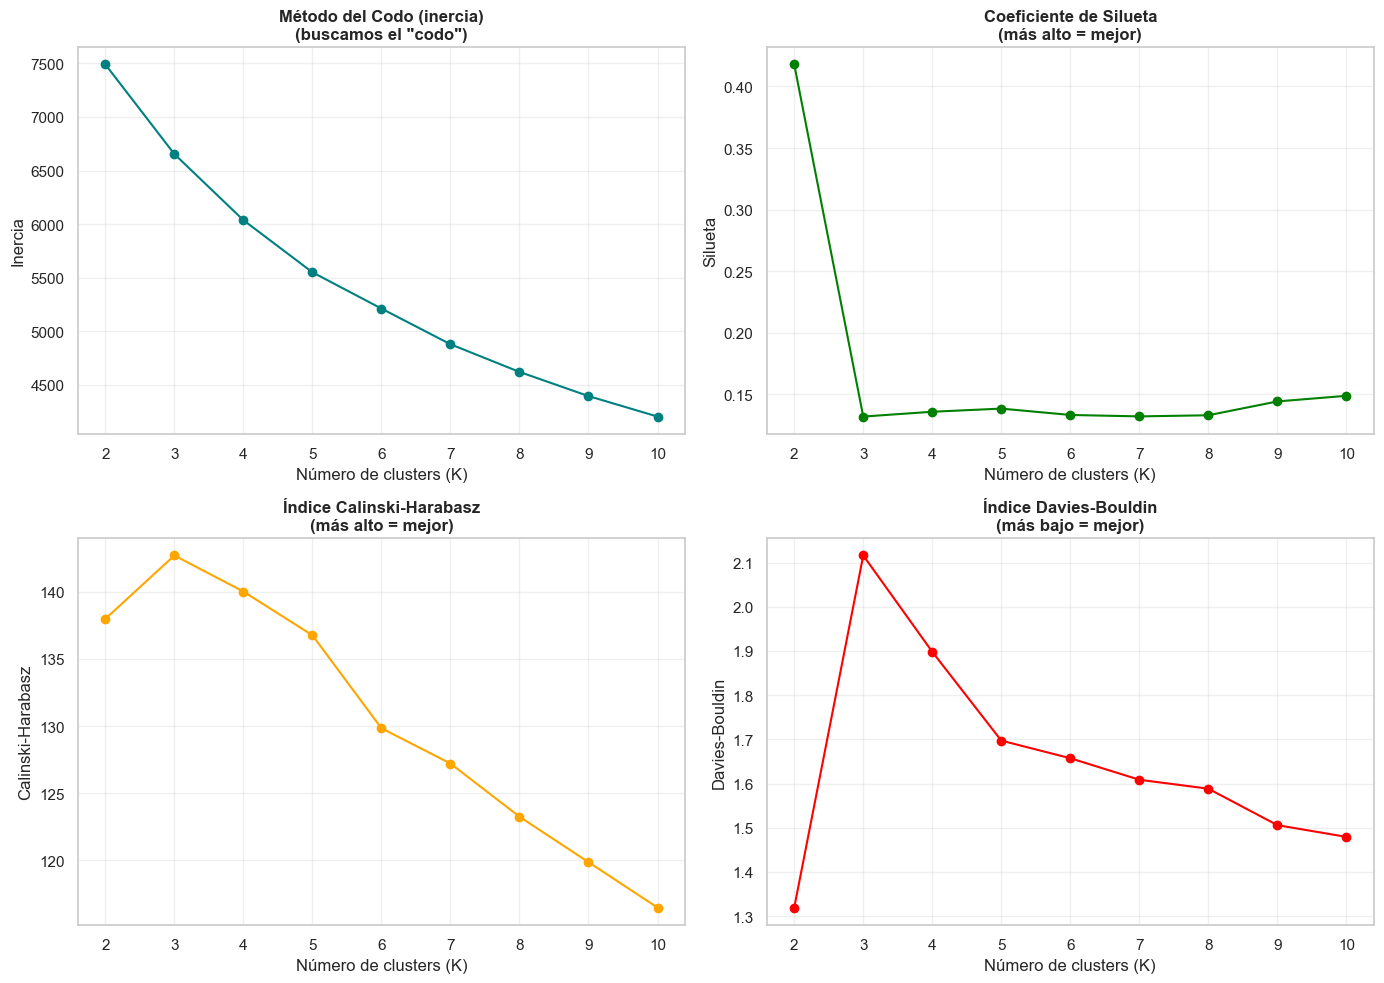

Resumen de métricas:
 K  Inercia  Silueta  Calinski  Davies
 2   7490.0    0.418     138.0   1.319
 3   6653.7    0.132     142.7   2.116
 4   6036.8    0.136     140.0   1.898
 5   5550.3    0.139     136.8   1.697
 6   5211.5    0.133     129.8   1.657
 7   4878.5    0.132     127.2   1.609
 8   4620.2    0.133     123.3   1.588
 9   4394.8    0.144     119.9   1.506
10   4203.6    0.149     116.5   1.479


In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Probaremos k entre 2 y 10
rango_k = range(2, 11)
inercia = []
silhouette = []
calinski = []
davies = []

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = kmeans.fit_predict(X_hibrido)
    
    inercia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_hibrido, etiquetas))
    calinski.append(calinski_harabasz_score(X_hibrido, etiquetas))
    davies.append(davies_bouldin_score(X_hibrido, etiquetas))

# Panel de 4 gráficos
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(rango_k, inercia, marker='o', color='teal')
axs[0, 0].set_title('Método del Codo (inercia)\n(buscamos el "codo")', fontweight='bold')
axs[0, 0].set_xlabel('Número de clusters (K)')
axs[0, 0].set_ylabel('Inercia')
axs[0, 0].set_xticks(rango_k); axs[0, 0].grid(alpha=0.3)

axs[0, 1].plot(rango_k, silhouette, marker='o', color='green')
axs[0, 1].set_title('Coeficiente de Silueta\n(más alto = mejor)', fontweight='bold')
axs[0, 1].set_xlabel('Número de clusters (K)')
axs[0, 1].set_ylabel('Silueta')
axs[0, 1].set_xticks(rango_k); axs[0, 1].grid(alpha=0.3)

axs[1, 0].plot(rango_k, calinski, marker='o', color='orange')
axs[1, 0].set_title('Índice Calinski-Harabasz\n(más alto = mejor)', fontweight='bold')
axs[1, 0].set_xlabel('Número de clusters (K)')
axs[1, 0].set_ylabel('Calinski-Harabasz')
axs[1, 0].set_xticks(rango_k); axs[1, 0].grid(alpha=0.3)

axs[1, 1].plot(rango_k, davies, marker='o', color='red')
axs[1, 1].set_title('Índice Davies-Bouldin\n(más bajo = mejor)', fontweight='bold')
axs[1, 1].set_xlabel('Número de clusters (K)')
axs[1, 1].set_ylabel('Davies-Bouldin')
axs[1, 1].set_xticks(rango_k); axs[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla resumen
import pandas as pd
resumen = pd.DataFrame({
    'K': list(rango_k),
    'Inercia': [round(x, 1) for x in inercia],
    'Silueta': [round(x, 3) for x in silhouette],
    'Calinski': [round(x, 1) for x in calinski],
    'Davies': [round(x, 3) for x in davies]
})
print("Resumen de métricas:")
print(resumen.to_string(index=False))

Las cuatro métricas no coinciden:

| Métrica | Mejor k | Valor |
|---|---|---|
| Coeficiente de Silueta | **k=2** | 0.418 |
| Davies-Bouldin (más bajo = mejor) | **k=2** | 1.319 |
| Calinski-Harabasz | **k=3** | 142.7 |
| Método del codo | sin codo claro | — |

Tres de las cuatro métricas apuntan a una estructura natural de 2 grupos muy bien separados. Sin embargo, k=2 produce perfiles demasiado gruesos para el objetivo clínico del análisis: el Ej5 pide identificar perfiles de pacientes útiles para el triaje y la detección de errores, y con solo dos grupos no se puede distinguir entre arquetipos clínicos relevantes (p. ej. paciente joven traumatológico vs anciano con vitales alteradas vs caso respiratorio crítico).

**Decisión**: elegimos k=5 como compromiso entre rigor metodológico y utilidad clínica:

- Davies-Bouldin mejora notablemente entre k=3 y k=5 (de 2.12 a 1.70), indicando que dentro de la pérdida de calidad respecto a k=2, k=5 es un punto estable.
- k=5 coincide con los 5 niveles del KTAS (escala de triaje real usada en urgencias), lo que facilitará la comparación entre los clusters obtenidos y la clasificación experta en el Ej5.
- Permite una granularidad suficiente para identificar arquetipos clínicos diferenciados sin caer en sobre-segmentación.

Reconocemos que las métricas favorecen k=2; priorizamos la utilidad analítica posterior sobre la separabilidad pura, dejando constancia explícita de esta decisión.

In [27]:
# Entrenamos el modelo final con k=5
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
etiquetas_finales = kmeans_final.fit_predict(X_hibrido)

# Añadimos las etiquetas al dataset (sin escalar, para ver valores reales)
df_resultados = X_kmeans.copy()
df_resultados['Cluster'] = etiquetas_finales

# Distribución de pacientes por cluster
print("Distribución de pacientes por cluster:")
print(df_resultados['Cluster'].value_counts().sort_index())
print(f"\nTotal pacientes: {len(df_resultados)}")

c:\Users\alexr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Distribución de pacientes por cluster:
Cluster
0    377
1    197
2     51
3    391
4     23
Name: count, dtype: int64

Total pacientes: 1039


La distribución es asimétrica pero coherente con lo esperado:

- Dos clusters mayoritarios (0 y 3, juntos el 73.9% del dataset) corresponden probablemente a los dos perfiles naturales detectados por las métricas con k=2: pacientes "tipo" del centro de urgencias.
- Un cluster intermedio (1, 19.0%) representa un perfil clínico diferenciado pero menos frecuente.
- Dos clusters minoritarios (2 con 51 pacientes y 4 con solo 23, juntos el 7.1%) recogen casos clínicamente extremos. Este resultado conecta con lo anticipado en el Ej2, donde detectamos valores muy alejados del centro (hasta ±7.9 desviaciones) en variables como Mental, Saturation y BT: k-means los ha aislado en grupos propios, en lugar de diluirlos en los clusters grandes.

Esta granularidad es ideal para el Ej5: si los clusters minoritarios concentran pacientes clínicamente críticos, podríamos comprobar si coinciden con tasas elevadas de errores de triaje (mistriage), lo que validaría el uso del clustering como herramienta auxiliar de detección.

Aunque el clustering se ha realizado sobre 9 variables, podemos hacer una primera lectura visual proyectando los grupos sobre dos de las variables clínicamente más representativas y con más variabilidad: Edad (eje X) y Frecuencia cardíaca (eje Y). Lo hacemos con un scatterplot coloreando cada paciente según el cluster al que pertenece, lo que permite ver de un vistazo si los grupos siguen algún patrón clínico claro. Esta vista 2D es una aproximación inicial; en el Ej4 utilizaremos PCA para obtener una proyección que aprovecha la información de todas las variables a la vez

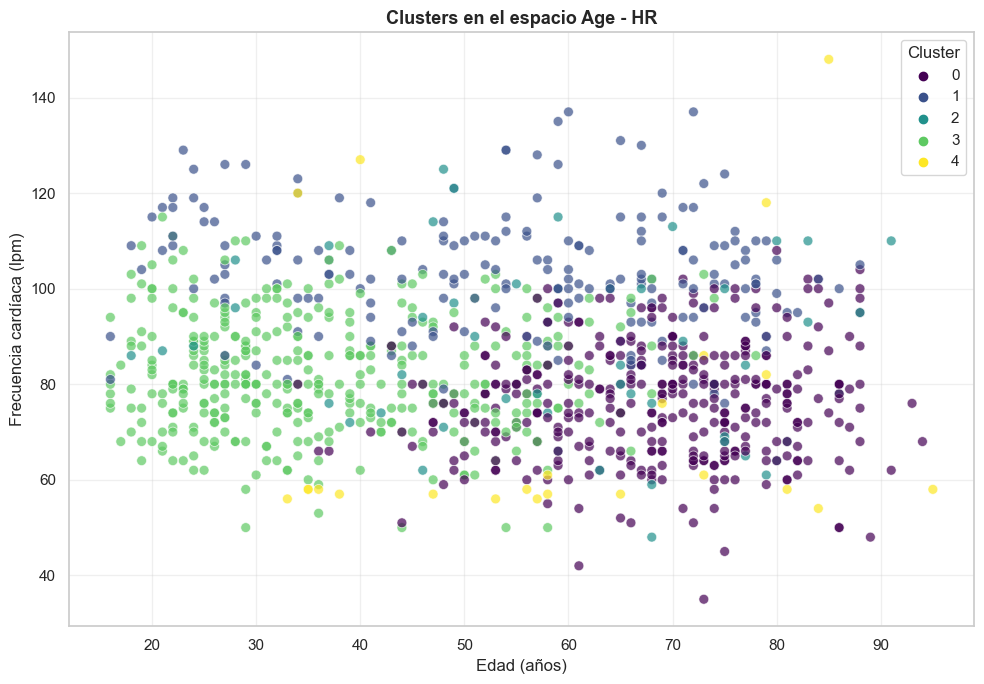

In [28]:
# Scatter 2D: Age vs HR coloreado por cluster
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_resultados,
    x='Age', y='HR',
    hue='Cluster',
    palette='viridis',
    alpha=0.7,
    s=50
)
plt.title('Clusters en el espacio Age - HR', fontsize=13, fontweight='bold')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia cardíaca (lpm)')
plt.legend(title='Cluster', loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Aunque hay solapamiento (es esperable: solo estamos viendo 2 de las 9 dimensiones), se aprecia que los clusters no se distribuyen al azar:

- El cluster 3 (verde) se concentra en pacientes jóvenes (15-50 años) con frecuencia cardíaca media-alta. Compatible con un perfil de paciente joven activo.
- El cluster 0 (morado) ocupa principalmente el rango de mayor edad (50-90 años) con frecuencias cardíacas medias. Perfil de paciente mayor sin grandes alteraciones cardíacas.
- El cluster 1 (azul) aparece disperso pero con tendencia a frecuencias cardíacas elevadas (>100 lpm), sugiriendo pacientes con taquicardia.
- Los clusters minoritarios 2 (verde-azul) y 4 (amarillo) aparecen muy dispersos, lo que confirma que su separación se debe a otras variables fuera de este plano (probablemente Saturation, BT o Mental).

### **Ejercicio 4**: utiliza técnicas de reducción de dimensionalidad (por ejemplo, PCA) para visualizar los datos en 2D.

En el Ej3 hemos trabajado con 9 variables, lo que dificulta visualizar los clusters en su espacio real (no podemos dibujar gráficos 9-dimensionales). Para resolverlo aplicamos Análisis de Componentes Principales (PCA), una técnica que resume las 9 variables originales en 2 nuevas componentes que capturan la mayor parte de la información (varianza) del dataset.

La idea es proyectar los datos en un plano 2D donde:

- Cada eje (PC1, PC2) es una combinación lineal de las 9 variables originales.
- La proyección conserva las distancias entre puntos lo mejor posible.
- Si los clusters se ven separados en este plano, validamos visualmente que el k-means ha encontrado una estructura real en los datos.

Importante: aplicamos PCA sobre la matriz híbrida escalada (X_hibrido), no sobre los datos sin escalar, porque PCA es sensible a la escala (variables con rangos grandes dominarían la proyección).

In [29]:
from sklearn.decomposition import PCA

# Aplicamos PCA a 2 componentes sobre la matriz híbrida (la misma usada en k-means)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_hibrido)

# Varianza explicada por cada componente
varianza_pc1 = pca.explained_variance_ratio_[0]
varianza_pc2 = pca.explained_variance_ratio_[1]
varianza_total = varianza_pc1 + varianza_pc2

print(f"Varianza explicada por PC1: {varianza_pc1:.2%}")
print(f"Varianza explicada por PC2: {varianza_pc2:.2%}")
print(f"Varianza explicada total (PC1 + PC2): {varianza_total:.2%}")

Varianza explicada por PC1: 19.58%
Varianza explicada por PC2: 15.64%
Varianza explicada total (PC1 + PC2): 35.21%


Las dos primeras componentes principales capturan el **35.21%** de la varianza total del dataset (PC1: 19.58%, PC2: 15.64%). Este valor no es alto, pero es coherente con la naturaleza del dataset: las 9 variables miden aspectos clínicos heterogéneos (edad, constantes vitales, dolor, lesión, estado mental), poco correlacionados entre sí, por lo que es difícil condensarlas en pocas dimensiones sin pérdida significativa.

Esto implica que la visualización 2D mostrará una **aproximación parcial** de la separación real entre clusters: si los clusters aparecen razonablemente diferenciados en el plano PC1-PC2, podemos afirmar que el clustering ha capturado estructura genuina (ya que vemos solo un tercio de la información). El solapamiento parcial entre algunos clusters es esperable y no invalida los resultados.

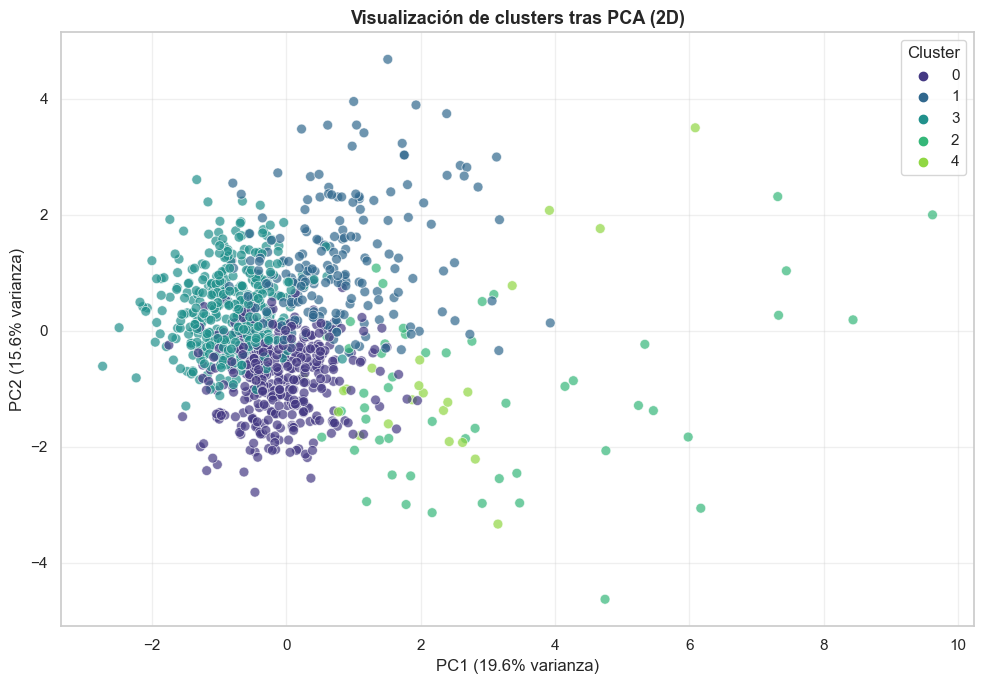

In [30]:
# Creamos un DataFrame con las componentes y las etiquetas de cluster
df_pca = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': df_resultados['Cluster'].astype(str)  # str para que se trate como categórico
})

# Visualización
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_pca,
    x='PC1', y='PC2',
    hue='Cluster',
    palette='viridis',
    alpha=0.7,
    s=50
)
plt.title('Visualización de clusters tras PCA (2D)', fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({varianza_pc1:.1%} varianza)')
plt.ylabel(f'PC2 ({varianza_pc2:.1%} varianza)')
plt.legend(title='Cluster', loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La proyección 2D permite varias observaciones clave:

- **Los clusters minoritarios 2 (verde) y 4 (amarillo) se diferencian claramente del resto del dataset.** El cluster 2 contiene puntos que se extienden hasta PC1 ≈ 10, muy alejados de la masa principal, lo que indica que k-means ha aislado correctamente a pacientes con valores clínicos extremos. El cluster 4 ocupa también una zona propia bien definida, confirmando que se trata de un perfil clínico real y no de ruido.
- **Los clusters mayoritarios 0, 1 y 3 se solapan parcialmente** pero tienen centroides visiblemente distintos: el cluster 3 se concentra en la zona superior-izquierda, el cluster 0 en la inferior-central, y el cluster 1 en la superior-derecha. El solapamiento en los bordes es esperable dado que solo estamos viendo el 35.2% de la varianza total.
- **PC1 actúa como un eje de "severidad clínica":** los pacientes con valores extremos en variables vitales se desplazan hacia la derecha, mientras que la mayoría de pacientes estables se concentran en PC1 < 3.

La visualización valida la decisión de k=5. Los grupos detectados por k-means tienen una estructura geométrica real, no son una segmentación arbitraria. En particular, los clusters minoritarios 2 y 4 emergen como candidatos a representar **perfiles clínicos críticos**, una hipótesis que exploraremos en el Ej5 cruzando los clusters con la variable `mistriage`.

### **Ejercicio 5**: interpreta los grupos analizando los centroides en el espacio original (no escalado). Identifica posibles perfiles de pacientes por grupo y usos reales del análisis (mejora del triaje, detección de errores, etc.). 

En el Ej3 obtuvimos 5 clusters trabajando sobre la matriz escalada (`X_hibrido`), donde las distancias entre puntos son comparables. Sin embargo, los centroides en ese espacio no son interpretables clínicamente: una "edad de -0.5 desviaciones" no dice nada a un médico.

Para extraer perfiles clínicos significativos, calculamos los centroides en el **espacio original (no escalado)**: las medias reales de cada variable por cluster, expresadas en sus unidades clínicas (años, lpm, mmHg, °C, %, etc.). Esta tabla nos permitirá identificar qué tipo de paciente representa cada cluster y proponer aplicaciones reales del análisis.

In [31]:
# Calculamos los centroides en el espacio ORIGINAL (sin escalar)
# Usamos df_resultados que tiene las variables sin escalar + la columna Cluster
centroides = df_resultados.groupby('Cluster').mean().round(1)

# Añadimos el tamaño de cada cluster
centroides['N_Pacientes'] = df_resultados['Cluster'].value_counts()

# Reordenamos columnas: tamaño primero
cols = ['N_Pacientes'] + [c for c in centroides.columns if c != 'N_Pacientes']
centroides = centroides[cols]

# Transponemos para que las variables sean filas y los clusters columnas (más legible)
print("Centroides en el espacio original (valores clínicos reales):")
display(centroides.T)

Centroides en el espacio original (valores clínicos reales):


Cluster,0,1,2,3,4
N_Pacientes,377.0,197.0,51.0,391.0,23.0
Age,68.5,53.8,59.6,36.9,59.3
Injury,0.1,0.1,0.2,0.3,0.3
Mental,1.0,1.0,2.4,1.0,1.0
NRS_pain,1.7,1.7,0.5,3.7,2.6
SBP,141.4,141.5,128.2,129.0,141.4
HR,76.3,103.9,86.4,82.0,72.9
RR,19.3,19.1,20.5,19.2,19.8
BT,36.4,37.1,36.8,36.5,36.5
Saturation,97.4,96.3,94.9,97.9,83.6


Analizando los centroides en el espacio original podemos asignar un perfil clínico claro a cada cluster:

| Cluster | N | Perfil clínico | Rasgos definitorios |
|---|---|---|---|
| **0** | 377 | **Anciano estable** | Edad alta (68.5), vitales normales, sin alteración mental, dolor bajo. Perfil de paciente mayor con dolencias crónicas o controladas. |
| **1** | 197 | **Adulto con cuadro infeccioso/inflamatorio** | Edad media (53.8), **taquicardia clara (HR 103.9 lpm)** y **febrícula (BT 37.1°C)**. Compatible con infección sistémica o respuesta inflamatoria. |
| **2** | 51 | **Emergencia neurológica** | **Estado mental alterado (Mental 2.4 vs 1.0 del resto)**, saturación ligeramente baja (94.9%), dolor mínimo (compatible con paciente con conciencia disminuida que no comunica). Perfil compatible con ictus, intoxicación o descenso del nivel de conciencia. |
| **3** | 391 | **Joven con dolor agudo / traumatológico** | **Edad baja (36.9 años)**, **dolor elevado (NRS 3.7)**, mayor proporción de lesiones (30%). Perfil clásico de urgencia traumatológica o dolor agudo en paciente joven. |
| **4** | 23 | **Emergencia respiratoria severa** ⚠️ | **Saturación crítica (83.6%)**, muy por debajo del umbral de hipoxia grave (<90%). El resto de vitales son aparentemente normales, lo que hace este perfil especialmente peligroso: pacientes que requieren oxigenoterapia inmediata pero podrían ser subestimados si solo se miran las constantes clásicas. |

Los 5 perfiles cubren todo el espectro de gravedad: desde pacientes estables (clusters 0 y 3) hasta emergencias críticas (clusters 2 y 4). El clustering ha logrado **separar a los pacientes críticos en grupos minoritarios propios**, exactamente lo que esperábamos según el Ej2 (los outliers de Mental, Saturation y BT aislados por k-means).

**Validación con `mistriage`: ¿el clustering detecta errores de triaje?**

En el Ej1 descubrimos que el **13.6% del dataset corresponde a errores de triaje** (4.7% overtriage, 8.9% undertriage). En aquel momento dejamos planteada una hipótesis fuerte:

> *Si el clustering identifica perfiles clínicos coherentes, los pacientes mal clasificados por las enfermeras (`mistriage > 0`) deberían concentrarse en clusters concretos — probablemente los que recogen perfiles atípicos o de difícil valoración a primera vista.*

Comprobamos ahora si esto se cumple, cruzando los clusters obtenidos con la variable `mistriage` original del dataset.

In [32]:
# Recuperamos mistriage del dataset original (asegurándonos de que las filas coinciden)
df_resultados['mistriage'] = df_limpio['mistriage'].values

# Versión binaria: 0 = triaje correcto, 1 = cualquier error (over o under)
df_resultados['mistriage_bin'] = (df_resultados['mistriage'] > 0).astype(int)

# Análisis por cluster
analisis = df_resultados.groupby('Cluster').agg(
    N_Pacientes=('mistriage', 'count'),
    Errores=('mistriage_bin', 'sum'),
    Tasa_Error=('mistriage_bin', 'mean')
)
analisis['Tasa_Error_%'] = (analisis['Tasa_Error'] * 100).round(1)
analisis = analisis.drop(columns=['Tasa_Error'])

# Añadimos también el desglose por tipo de error
desglose = df_resultados.groupby(['Cluster', 'mistriage']).size().unstack(fill_value=0)
desglose.columns = ['Correcto (0)', 'Overtriage (1)', 'Undertriage (2)']

print("Tasa de errores de triaje por cluster:")
display(analisis)

print("\nDesglose por tipo de error:")
display(desglose)

# Tasa global de referencia
tasa_global = df_resultados['mistriage_bin'].mean() * 100
print(f"\nTasa global de errores en el dataset: {tasa_global:.1f}%")

Tasa de errores de triaje por cluster:


,N_Pacientes,Errores,Tasa_Error_%
Cluster,,,
0,377,42,11.1
1,197,33,16.8
2,51,6,11.8
3,391,57,14.6
4,23,3,13.0



Desglose por tipo de error:


,Correcto (0),Overtriage (1),Undertriage (2)
Cluster,,,
0,335,12,30
1,164,13,20
2,45,2,4
3,334,22,35
4,20,0,3



Tasa global de errores en el dataset: 13.6%


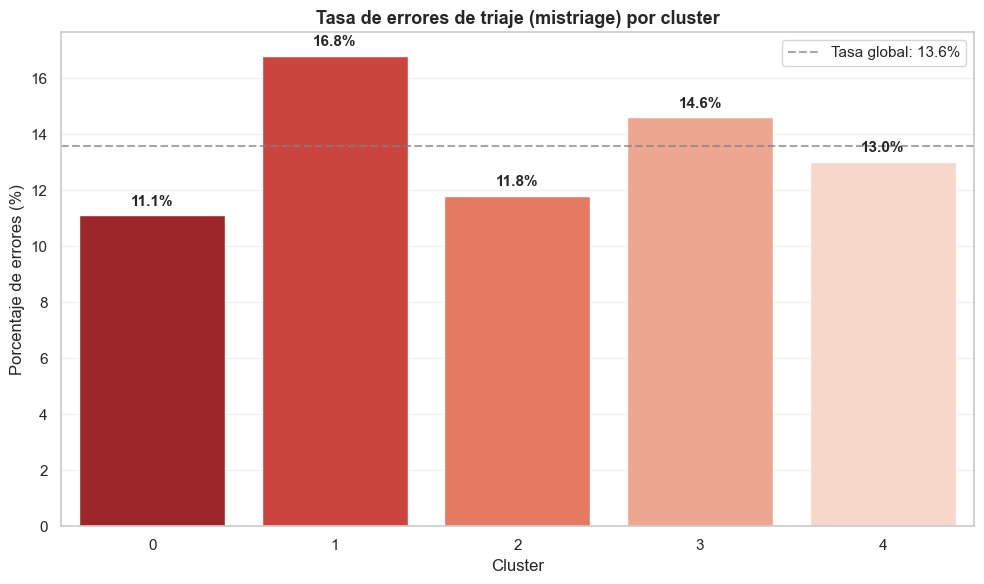

In [33]:
# Gráfico de barras con la tasa de error por cluster
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=analisis.index.astype(str),
    y='Tasa_Error_%',
    data=analisis.reset_index(),
    palette='Reds_r'
)

# Etiquetas con porcentajes encima de cada barra
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{altura:.1f}%',
                (p.get_x() + p.get_width()/2, altura),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

# Línea horizontal con la tasa global de referencia
plt.axhline(tasa_global, color='gray', linestyle='--', alpha=0.7,
            label=f'Tasa global: {tasa_global:.1f}%')

plt.title('Tasa de errores de triaje (mistriage) por cluster', fontsize=13, fontweight='bold')
plt.ylabel('Porcentaje de errores (%)')
plt.xlabel('Cluster')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Resultados del cruce con `mistriage`**

| Cluster | Perfil clínico | Tasa de error | vs global (13.6%) |
|---|---|---|---|
| 0 | Anciano estable | 11.1% | -2.5 pp |
| 1 | Cuadro infeccioso/inflamatorio | **16.8%** | **+3.2 pp** |
| 2 | Emergencia neurológica | 11.8% | -1.8 pp |
| 3 | Joven con dolor agudo | 14.6% | +1.0 pp |
| 4 | Emergencia respiratoria | 13.0% | -0.6 pp |

**Conclusión: la hipótesis inicial se confirma de forma parcial.** No todos los clusters críticos concentran errores de triaje como esperábamos. La diferencia entre el cluster con más y menos errores (5.7 puntos porcentuales) es modesta, lo que indica que k-means **por sí solo no es una herramienta suficiente para detectar errores de triaje sistemáticos**.

Sin embargo, sí emerge un patrón con sentido clínico:

- El **cluster 1 (cuadro infeccioso/inflamatorio)** presenta la tasa de error más alta (16.8%, +3.2 pp sobre la media). Esto encaja con la realidad clínica: los pacientes con febrícula y taquicardia son **especialmente difíciles de triar a primera vista**, ya que sus síntomas iniciales pueden parecer leves pero ocultar cuadros graves como sepsis incipientes. Es el perfil donde el ojo humano se equivoca más.
- El **cluster 0 (anciano estable)** y el **cluster 2 (emergencia neurológica)** tienen las tasas más bajas. Ambos extremos del espectro de gravedad son fáciles de clasificar para una enfermera experimentada: muy estable o claramente crítico.
- En el **desglose por tipo de error**, el undertriage (subestimar gravedad) domina sobre el overtriage en todos los clusters, lo que refuerza el patrón visto en el Ej1: el error sistemático del triaje en este dataset tiende a la infraestimación, no a la sobreestimación.

### **Conclusiones finales y usos reales del análisis**

El clustering no supervisado aplicado al dataset ha permitido identificar **5 arquetipos clínicos diferenciados** de pacientes de urgencias, validados visualmente mediante PCA. Los perfiles obtenidos cubren el espectro completo de complejidad clínica, desde pacientes estables hasta emergencias críticas.

**Aplicaciones prácticas propuestas para el Grupo Hospitalario JENNER & PHIPPS S.A.:**

1. **Sistema de apoyo al triaje:** integrar el modelo como una **segunda opinión automatizada** que asigne a cada paciente entrante uno de los 5 perfiles clínicos. La enfermera de triaje vería el perfil sugerido junto a su propia valoración, lo que sería especialmente útil en clusters difíciles como el **1 (infeccioso/inflamatorio)**, donde el undertriage es más frecuente.

2. **Alerta temprana en perfiles críticos:** los clusters 2 (emergencia neurológica) y 4 (emergencia respiratoria con saturación < 84%) son **minoritarios pero potencialmente fatales**. Una alerta automática cuando un paciente cae en estos clusters permitiría priorización inmediata de recursos.

3. **Auditoría retrospectiva del triaje:** aunque el clustering no detecta errores con precisión suficiente para usarse como filtro automático, sí permite **identificar perfiles de riesgo** donde concentrar revisiones de calidad o formación específica del personal (en este caso, el cluster 1 sería el candidato prioritario).

4. **Optimización de recursos:** conocer la distribución de pacientes por perfil clínico permite **dimensionar mejor los equipos** y los recursos materiales (camas, monitores, oxígeno) según el flujo esperado de cada arquetipo en distintos turnos.

5. **Comparación entre centros:** dado que el dataset cubre dos hospitales (Local y Regional), aplicar el mismo modelo en cada centro permitiría detectar diferencias en el mix de pacientes y ajustar protocolos de derivación.

**Limitaciones reconocidas:**

- Los 2 componentes principales del PCA solo explican el 35% de la varianza, lo que indica que la separación entre clusters en 2D es parcial.
- El 55% de la `Saturation` fue imputada mediante RandomForest, una limitación heredada del diseño del estudio.
- Las métricas internas (silueta) favorecen k=2; la elección de k=5 se justificó por utilidad clínica, no por separabilidad pura.

A pesar de estas limitaciones, el análisis demuestra que técnicas no supervisadas pueden aportar **una mirada estructurada y reproducible** sobre poblaciones de urgencias, complementando la valoración clínica humana sin sustituirla.